# Load all routines path necessary for the FPDEM code to run (scripts/, src/ and environment path)

In [1]:
import sys
src_path = "/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src"
sys.path.append(f"{src_path}")
scripts_path = "/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/scripts"
sys.path.append(f"{scripts_path}")

# Define all parameters of FPDEM

Fill in all the parameters necessary to run this notebook.

In [2]:
model_main_path = "/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/testcases/Lajeodo"
model_pixc_main_path = "/work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Lajeodo"

# Pixc list (1 space blank between each file)
pixc_files = f"{model_pixc_main_path}/input/pixc/SWOT_L2_HR_PIXC_*.nc"

# PixcVec list (1 space blank between each file)ls 
pixcvec_files = f"{model_pixc_main_path}/input/pixcvec/SWOT_L2_HR_PIXCVec_*.nc"

# Output directory
output_dir = f"{model_main_path}/output_nbk"

# Output file name extension
tile_name = "29S51W"
first_date = "20240111T184700"
last_date = "20241119T180313"


# Geographical extrema of the studied region : filtering of points applied on this box
latitude_min = -30.25
latitude_max = -29.65
longitude_min = -52.08
longitude_max = -51.48


# Select model approach : 
# Bathtub ring method or a mix of bathtub and clustering and direct extraction of land
approach = 'mixed' # mixed or bathtub


# Pekel info : 
# Path and name of the Pekel occurrences file
pekel_path = "/work/datalake/static_aux/MASQUES/PEKEL/data2021/occurrence/occurrence.vrt"

# SWORD info : 
# Path to SWORD database
sword_path = "/work/SWOT/swotdev/swotpub/BD/BD_rivers/SWORD_v17/shp"
# Paths and names of hydrobasins (level1 and level2) files
hydrobasin_lv1_file = "/work/SWOT/swotdev/swotpub/BD/major_basins/HydroBASINS/level1/hybas_lev01_v1c.shp"
hydrobasin_lv2_file = "/work/SWOT/swotdev/swotpub/BD/major_basins/HydroBASINS/level2/hybas_lev02_v1c.shp"

# Swot science orbits and tiles path and filename
swot_tiles_file = "/work/SWOT/swotdev/swotdev/stephag/orbits/swot_science_hr_2.0s_4.0s_June2019-v3_swath_tile.shp"


#
# Mask
#
# To filter points around a specific lake, river, 
# or filter only points present in Pekel occurrences (1->100%; with a buffer if mask_buffer_size != 0)
# 0 : no; 1 : yes (with PLD); 2 : yes (with Pekel); 3 : yes (with Sword)
use_mask = 0
# Buffer in soil geometry (degrees)
mask_buffer_size = 0.02 # Optional parameter : only required if use_mask >= 1
# PLD info
lake_id = 0 # Optional parameter : only required if use_mask = 1
pld_path = "/work/SWOT/swotdev/swotpub/BD/BD_lakes/PLD/Nom/" # Optional parameter : only required if use_mask = 1


# Plot
plot = "yes2" # Options: no, yes1 (only for Python script), yes2 (for notebook)


#
# PIXC pre-processing
#
# Range value of the crosstrack minimum value wanted
cross_track_min = 10000.
# Minimum surface of a water body kept for FPDEM method
threshold = 100000. # Minimum surface of a water body kept for FPDEM method


#
# Clustering method params : performed on WATER_LAND labels (optional if approach='bathtub')
#
# zscore or isolation_forest
clustering_outlier_filter_method = "isolation_forest"
# kmeans, birch, hdbscan_tsne or hdbscan_umap are possible choices
clustering_method = "kmeans"
# Once the clustering is performed, all water bodies will get their contour extracted;
# Choose either the bathtub ring method (like it is already done for WATER labels) 
# or the geopandas concave hull method (might be better for small water bodies)
clustering_contour = "concavehull" # bathtub or concavehull


#
# Filtering
#
# Pekel filtering
# At the beginning of the bathy extraction,
# Filtering Dark water, all PIXC points within Pekel occurrences > {chosen value}% are kept
filtering_pekel_val_DW = 95
# At the end of the bathy extraction,
# Filter out all points within Pekel occurrences > {chosen value}% 
filtering_pekel_end = 'yes' # yes or no
filtering_pekel_end_val = 99 # Threshold occurrence value

# Quality flags for filtering
# At the beginning of the bathy extraction
# Filter sig0_qual: 'no' = do not filter; 'yes' = keep only good points (i.e., sig0_qual=0)
sig0_qual = 'yes' # yes or no
# At the end of the bathy extraction
# Select the bit threshold for each quality flag, all FPDEM/PIXC points with a bit higher than the chosen value are filtered out
classification_qual = 33554432
geolocation_qual = 33554432

# Isolated points filtering (with DBSCAN) :
# Maximum distance in degrees for two points to be considered neighbors
distance_to_neighbors = 0.001
# All points with less meighbors than the chosen value are filtered out
number_of_neighbors = 5

# Labeling water bodies :
# Remove objects smaller than or equal to chosen size
body_min_size = 1000
# Connectivity defining the neighborhood of a pixel
body_connectivity = 1


#
# Extract area / Obtain polygons for rasterisation
#
# Concave hull ratio (with geopandas)
plg_ch_ratio = 0.005


#
# Raster
#
# Choose between 'latlon' or 'utm' for the definition of the raster grid
raster_mode = "latlon" # utm or latlon
# The resolution is in degrees for latlon mode and meters for utm mode
# for example: if latlon => 0.000277777; if utm > 100
raster_resolution = 0.000277777

Here are all the imports necessary for the python code.

In [3]:
# Miscellaneous
import os
import copy
import logging
import pandas as pd
import geopandas as gpd
import numpy as np
import utm
import random
import shapely
from shapely.geometry import Point, MultiPoint

# Plotting libraries
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.img_tiles import GoogleTiles
wgs84 = ccrs.PlateCarree(globe=ccrs.Globe(ellipse='WGS84'))
geodetic = ccrs.Geodetic(globe=ccrs.Globe(datum='WGS84'))
tiler = GoogleTiles(style="satellite")

# FPDEM classes/routines
from process_floodplain import Floodplain

from clustering_method import Clustering_Method

from process_extract_area import Extract_Area

from process_raster import FPDEM_Raster

from nc import PixcReader

from process import (pre_processing_pixc, get_range_azimuth_extrema, prepare_clustering_image,
                     find_attributes, remove_borders, filter_data_based_on_quality_flag,
                     final_filtering_FPDEM_results)

from water_or_land import (compute_label_and_remove_small_object, compute_subwater_extract_from_label,
                           find_body_category)

from Pekel_Sword_PLD_intersect import (get_tiles_geom, get_PLD_mask, get_Pekel_mask, extract_Pekel_polygon,
                                       get_reach_node_info, get_poly_sword_from_reach)

from names import (compute_name, FPDEM_BASENAME, FPDEM_POINTCLOUD_BASENAME, MASK_SUFFIX, FPDEM_RASTER_BASENAME)


In [4]:
# Initialize logging
level = getattr(logging, "INFO")
logging.basicConfig(filename=None, format='%(asctime)s [%(levelname)s] %(message)s', level=level)

# Initialize FPDEM workflow

Create the output directory

In [5]:
if os.path.isdir(output_dir) is False:
    os.mkdir(output_dir)

Get the names of all PIXC (and PIXCVec if there are any) and get the list of tiles information

In [6]:
# Get the list of PIXC and PIXCVEC files
inppixc = os.popen("ls " + pixc_files).readlines()
inpvec = os.popen("ls " + pixcvec_files).readlines()
inputpixcfiles = []
inputvecfiles = []
list_tile_info = []
for i in range(0, len(inppixc)):
    inppixc[i] = inppixc[i].rstrip('\n')
    find = False
    for k in range(0, len(inpvec)):
        inpvec[k] = inpvec[k].rstrip('\n')
        if (inppixc[i].split("_PIXC_")[1].split("_P")[0] == inpvec[k].split("_PIXCVec_")[1].split("_P")[0]) \
            and (find == False):
            inputpixcfiles.append(inppixc[i])
            inputvecfiles.append(inpvec[k])
            find = True
    if find == False:  
        print("PIXCVec file is missing for date " + inppixc[i].split("_PIXC_")[1].split("_PI")[0] + 
              "  => replaced by PIXC")
        inputpixcfiles.append(inppixc[i])
        inputvecfiles.append(inppixc[i])
    if inppixc[i].split('/')[-1][20:28] not in list_tile_info:
        list_tile_info.append(inppixc[i].split('/')[-1][20:28])
print('List of PIXC files: ', inputpixcfiles)
print('List of tiles used: ', list_tile_info)

PIXCVec file is missing for date 030_214_207L_20250324T223340_20250324T223351  => replaced by PIXC
PIXCVec file is missing for date 031_214_207L_20250414T191844_20250414T191855  => replaced by PIXC
PIXCVec file is missing for date 032_214_207L_20250505T160348_20250505T160359  => replaced by PIXC
List of PIXC files:  ['/work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Lajeodo/input/pixc/SWOT_L2_HR_PIXC_030_214_207L_20250324T223340_20250324T223351_PIC2_01.nc', '/work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Lajeodo/input/pixc/SWOT_L2_HR_PIXC_031_214_207L_20250414T191844_20250414T191855_PIC2_01.nc', '/work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Lajeodo/input/pixc/SWOT_L2_HR_PIXC_032_214_207L_20250505T160348_20250505T160359_PIC2_01.nc']
List of tiles used:  ['214_207L']


ls: impossible d'accéder à '/work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Lajeodo/input/pixcvec/SWOT_L2_HR_PIXCVec_*.nc': No such file or directory


Read Pekel file and get the polygon mask depending on chosen occurrences for the studied area

In [7]:
# Get the geometry of the used PIXC tiles to clip Pekel and SWORD data
pixc_tiles_geom = get_tiles_geom(list_tile_info, swot_tiles_file)

# Pekel info
data_pekel = get_Pekel_mask(pekel_path, pixc_tiles_geom.geometry.values[0])

# Polygon of Pekel used in parametrization of water bodies
pekel_0_100_poly = extract_Pekel_polygon(data_pekel, 
                                         occ_min=0, occ_max=100, 
                                         bufsize=0.)

# Polygon of Pekel used to select dark water points
try:
    pekel_X_100_poly = extract_Pekel_polygon(data_pekel, 
                                             occ_min=filtering_pekel_val_DW, occ_max=100, 
                                             bufsize=0.)
except:
    logging.info(f"    No points in Pekel occurrences > {filtering_pekel_val_DW}% for this region")
    pekel_X_100_poly = None # In some regions water occurrence above 95% does not exist
    
pekel_X2_100_poly = None 
if filtering_pekel_end == 'yes': 
    # Polygon of Pekel used to select dark water points
    try:
        pekel_X2_100_poly = extract_Pekel_polygon(data_pekel, 
                                                  occ_min=filtering_pekel_end_val, occ_max=100,
                                                  bufsize=0.)
    except:
        logging.warning(f"    No points in Pekel occurrences > {filtering_pekel_end_val}% for this region")
        pekel_X2_100_poly = None # In some regions water occurrence above 95% does not exist                                              bufsize=0.)

Read SWORD file corresponding to studied region and get the polygon using reaches information

In [8]:
try:
    # SWORD info
    df_reach_data, df_node_data = get_reach_node_info(pixc_tiles_geom,
                                                      sword_path, hydrobasin_lv1_file, hydrobasin_lv2_file)
    # Polygon of the SWORD used in parametrization of water bodies
    poly_sword = get_poly_sword_from_reach(df_reach_data, buffer_size=0.)
except:
    poly_sword = None

2026-02-12 14:26:24,765 [INFO]     Continent number: [6], ['SA'] -- Hydrobasin number: [64]


Show the Pekel (for Dark Water) and SWORD masks on the studied area

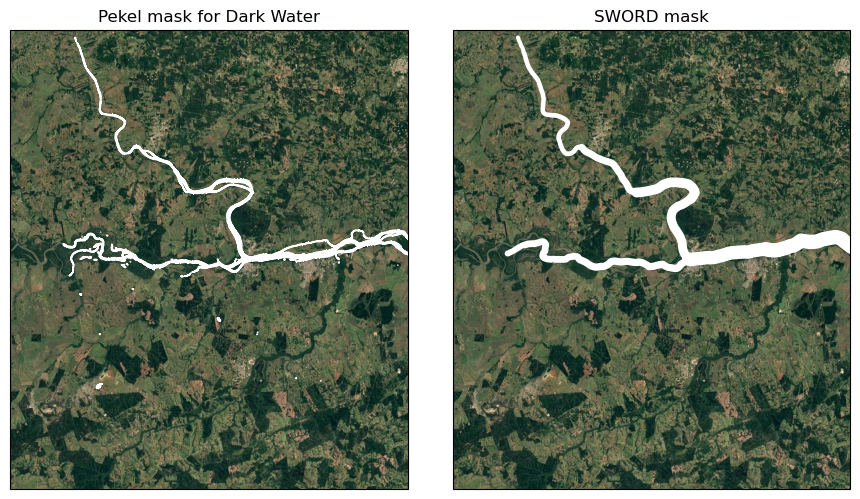

In [9]:
extent = [longitude_min, longitude_max, latitude_min, latitude_max]

fig = plt.figure(figsize=(9,5), layout='tight')
ax1 = fig.add_subplot(1, 2, 1, projection=tiler.crs)
ax1.set_title('Pekel mask for Dark Water')
ax1.set_extent(extent, geodetic)
ax1.add_image(tiler, 11)
ax1.add_geometries(pekel_X_100_poly, wgs84, edgecolor='white', facecolor='white')

if poly_sword is not None:
    ax2 = fig.add_subplot(1, 2, 2, projection=tiler.crs)
    ax2.set_title('SWORD mask')
    ax2.set_extent(extent, geodetic)
    ax2.add_image(tiler, 11)
    ax2.add_geometries(poly_sword, wgs84, edgecolor='white', facecolor='white')
    
plt.show()

Get the mask polygon if the user wants to reduce the studied region (use of Pekel, PLD or SWORD)

In [10]:
# Create the polygon mask needed for intersection with PIXC to limit the number of points
if use_mask == 1:
    print('PLD Mask intersection will be performed\n')
    polygon_mask = get_PLD_mask(lake_id, pld_path, inputpixcfiles[0])
elif use_mask == 2:
    print('Pekel Mask intersection will be performed\n')
    polygon_mask = extract_Pekel_polygon(data_pekel, occ_min=0, occ_max=100, bufsize=mask_buffer_size)
elif use_mask == 3:
    print('Sword Mask intersection will be performed\n')
    polygon_mask = get_poly_sword_from_reach(df_reach_data, buffer_size=mask_buffer_size)
else:
    polygon_mask = None

# Extracting bathymetry points from PIXC

Here is the main part of the notebook where the bathymetry points will be extracted for each PIXC in the list (previously determined).

For each PIXC, all PIXC points are labelized into 'water' bodies. On each body, we either apply the Bathtub Ring method or we categorize them into land, water or water-land depending on the option chosen by the user at the beginning of the notebook. For land bodies a direct extraction is performed. On water bodies the Bathtub Ring method is applied and on water-land bodies we clusterize them to separate water from land and then apply the Bathtub Ring method or do a direct extraction respectively.

At the end of the cell (still on each PIXC), the borders of the PIXC tiles are removed to eliminate false contours/bathymetries and some filtering based on quality flags is applied.

All PIXC results are merged into one single Dataframe.

2026-02-12 14:26:39,142 [INFO] PIXC: /work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Lajeodo/input/pixc/SWOT_L2_HR_PIXC_030_214_207L_20250324T223340_20250324T223351_PIC2_01.nc


Processing PIXC 1/3


2026-02-12 14:27:10,505 [INFO] Extract water points
2026-02-12 14:27:10,590 [INFO] Remove pixels too close to near_range
2026-02-12 14:27:13,219 [INFO] Extract contiguous water points by keeping only water bodies whose area is greater than threshold


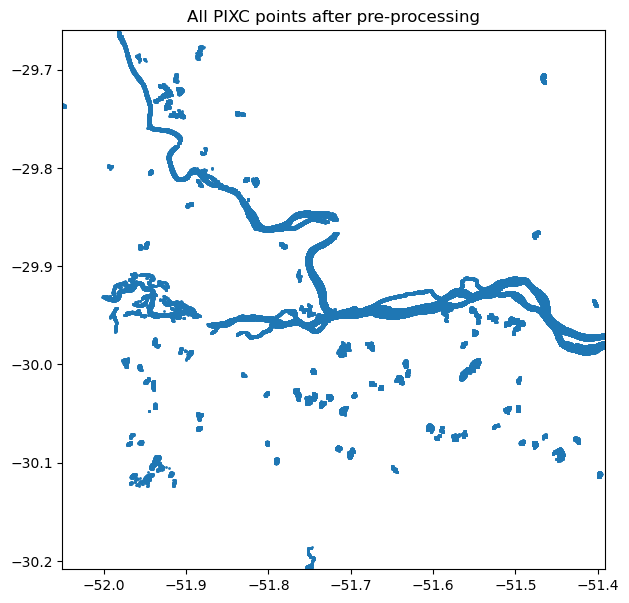

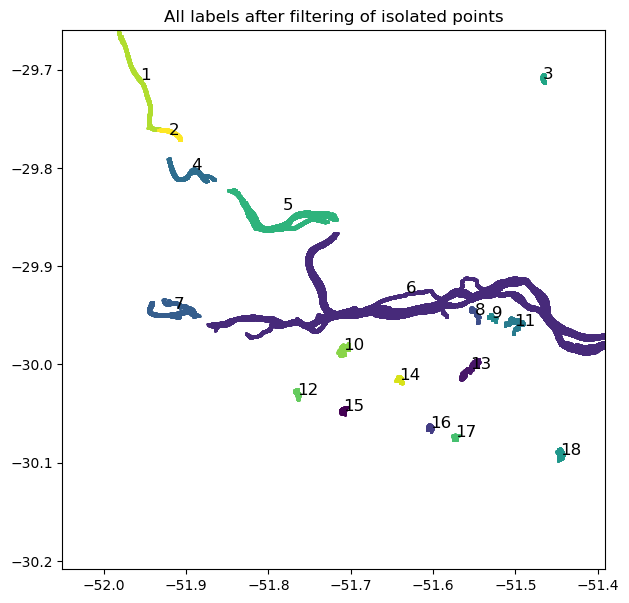

2026-02-12 14:27:20,076 [INFO] Ratio pekel, ratio sword: 0.8935980370287754, 0.9895159491412001
2026-02-12 14:27:20,076 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):17.246248245239258, -0.014136224053800106, -0.35402050614356995, 0.07004523277282715, 0.23981451988220215, 0.998392497176876, 0.9910853359618371


Number of water bodies found : 18

Processing Label 1 / 18


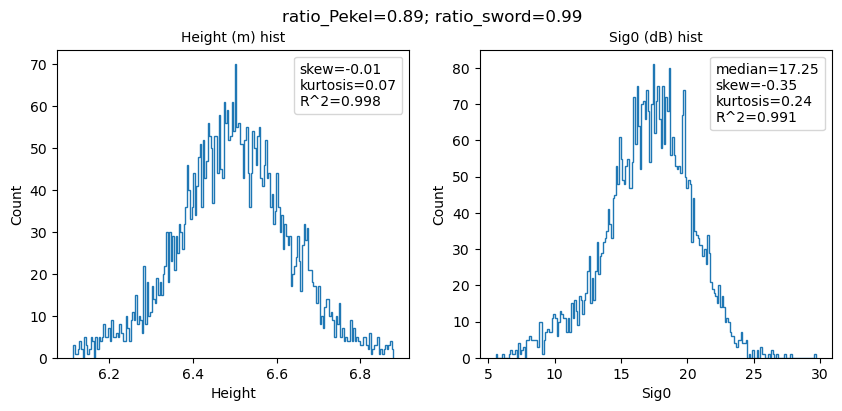

2026-02-12 14:27:20,377 [INFO] Ratio pekel, ratio sword: 0.916260162601626, 1.0
2026-02-12 14:27:20,378 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):17.543697357177734, -0.028857817873358727, -1.0501675605773926, 0.0735785961151123, 1.6530203819274902, 0.9977959304896764, 0.9401125885785051


Body type: WATER
Bathtub ring method is applied

Processing Label 2 / 18


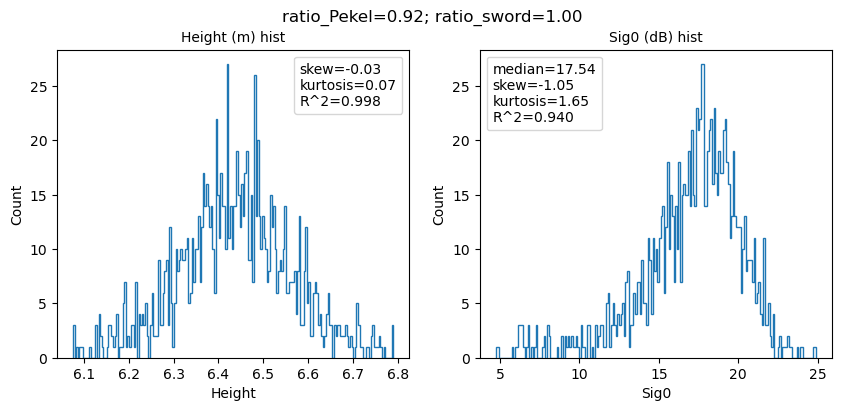

/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 14:27:20,619 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 14:27:20,619 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):8.256631851196289, -0.14462588727474213, -0.13874934613704681, -0.2950456142425537, -0.3412144184112549, 0.9968590232005595, 0.9962423956172842


Body type: WATER
Bathtub ring method is applied

Processing Label 3 / 18


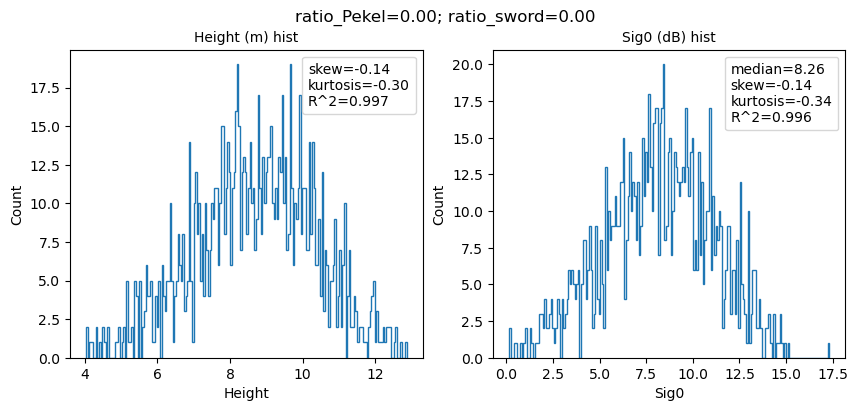

2026-02-12 14:27:20,870 [INFO] Ratio pekel, ratio sword: 0.8954081632653061, 0.9875
2026-02-12 14:27:20,871 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):18.333942413330078, 0.019206508994102478, -0.6011732816696167, 0.5938971042633057, 0.7689342498779297, 0.9948715202132382, 0.9771746576267218


Body type: LAND

Processing Label 4 / 18


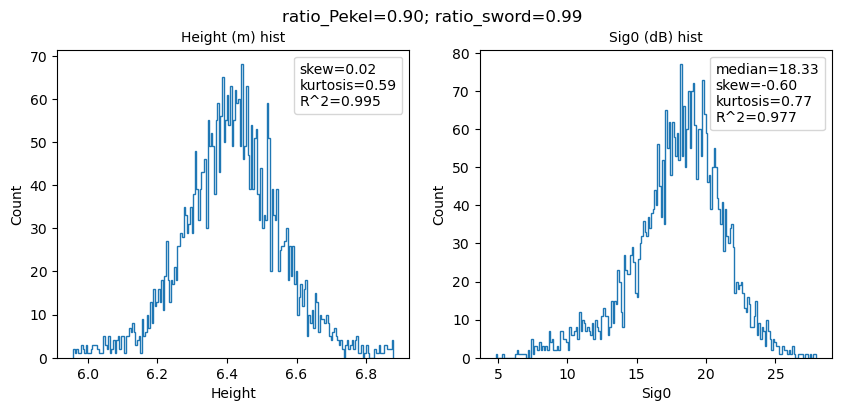

2026-02-12 14:27:21,174 [INFO] Ratio pekel, ratio sword: 0.9499498063960993, 0.9633825708685884
2026-02-12 14:27:21,175 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):16.810678482055664, -0.05680902674794197, -0.8761618137359619, 0.2519702911376953, 1.4947161674499512, 0.9985424457550401, 0.9596877778966391


Body type: WATER
Bathtub ring method is applied

Processing Label 5 / 18


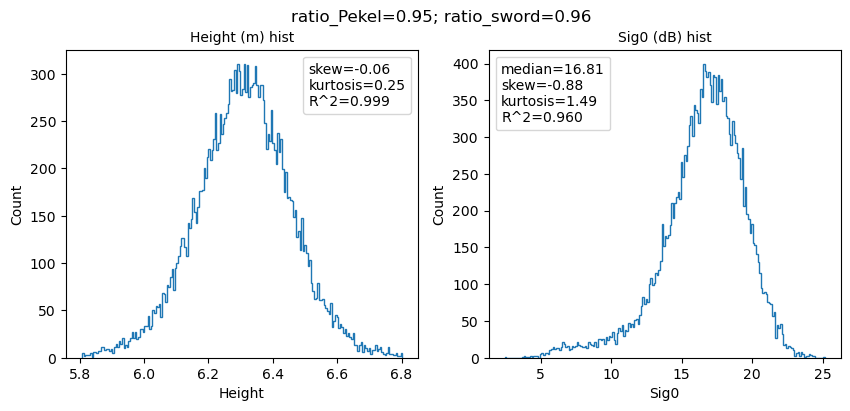

Body type: WATER
Bathtub ring method is applied


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.839835309757611 -29.823420712969522
  return _ogr.Geometry_IsValid(self, *args)



Processing Label 6 / 18


2026-02-12 14:27:22,008 [INFO] Ratio pekel, ratio sword: 0.6784641735655152, 0.63082500713674
2026-02-12 14:27:22,008 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.904356002807617, -0.43106719851493835, -0.38627392053604126, 0.001127481460571289, 0.5411057472229004, 0.9857407106520113, 0.9906704436194944


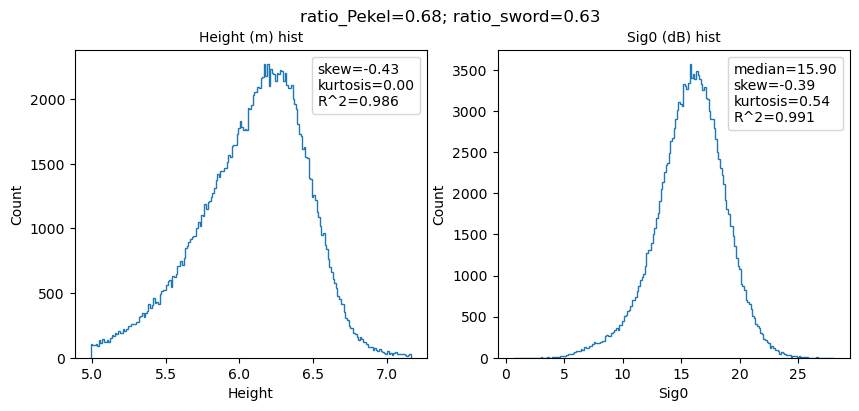

Body type: WATER
Bathtub ring method is applied


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.395617091456145 -29.969734292977279
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:27:31,634 [INFO] Ratio pekel, ratio sword: 0.9739669421487603, 0.7621900826446281
2026-02-12 14:27:31,635 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):17.463565826416016, -0.4208831787109375, -0.19639980792999268, 0.2674295902252197, 0.6518039703369141, 0.9819584802383904, 0.9917572664526683



Processing Label 7 / 18


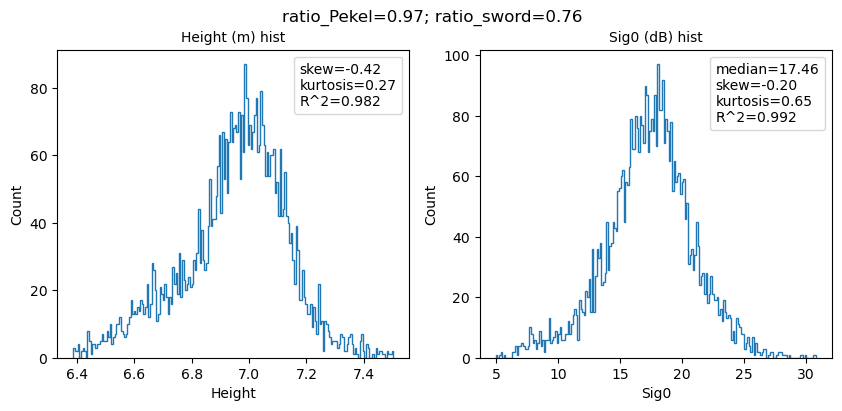

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.909838220431922 -29.940626890565145
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:27:31,915 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 14:27:31,916 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.117162704467773, -0.05412150174379349, -0.5412180423736572, 0.15868115425109863, -0.3413996696472168, 0.9973515403628002, 0.9659326018868529


Body type: WATER
Bathtub ring method is applied

Processing Label 8 / 18


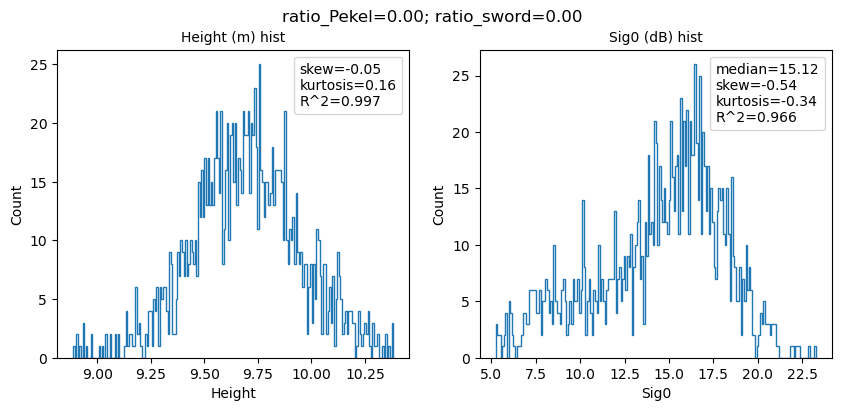

2026-02-12 14:27:32,154 [INFO] Ratio pekel, ratio sword: 0.8162274618585298, 0.0
2026-02-12 14:27:32,154 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.485363006591797, -0.029697902500629425, -0.6252002716064453, 0.3874490261077881, 0.3007068634033203, 0.9967341068842527, 0.972946316281856


Body type: LAND

Processing Label 9 / 18


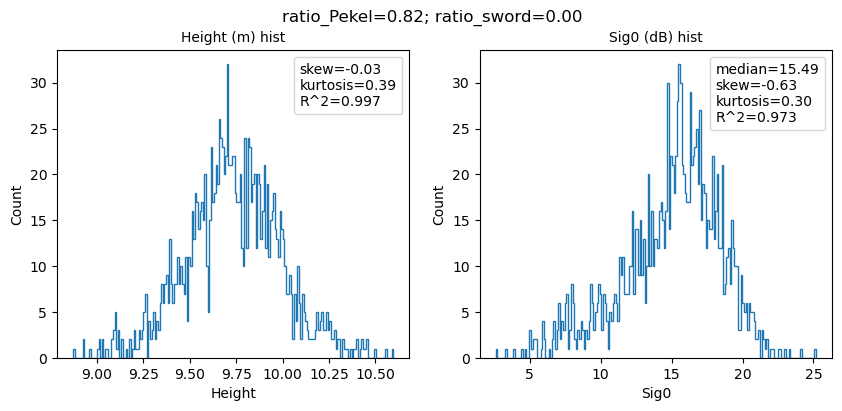

2026-02-12 14:27:32,404 [INFO] Ratio pekel, ratio sword: 0.9707977207977208, 0.0
2026-02-12 14:27:32,404 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):16.723556518554688, 0.11164629459381104, -0.940243661403656, 0.23898673057556152, 1.6096229553222656, 0.9976112760086758, 0.9510106419438281


Body type: WATER
Bathtub ring method is applied

Processing Label 10 / 18


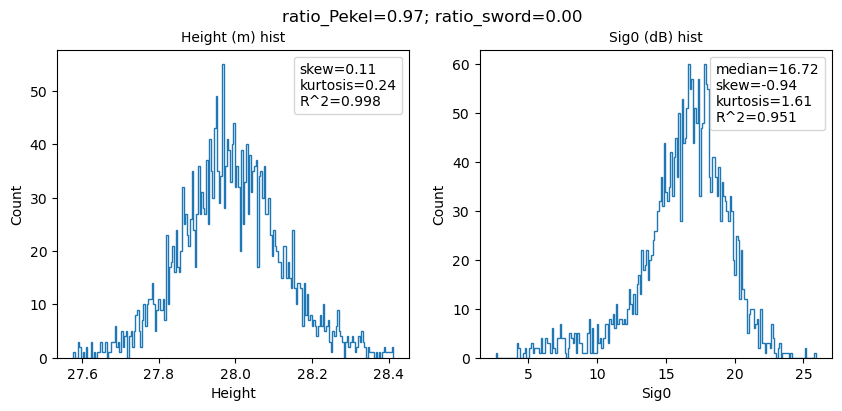

2026-02-12 14:27:32,653 [INFO] Ratio pekel, ratio sword: 0.9525098937721308, 0.0
2026-02-12 14:27:32,654 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.948217391967773, -0.030913857743144035, -0.6292093992233276, -0.0854494571685791, 0.3359236717224121, 0.9992994258428584, 0.9741926479693055


Body type: WATER
Bathtub ring method is applied

Processing Label 11 / 18


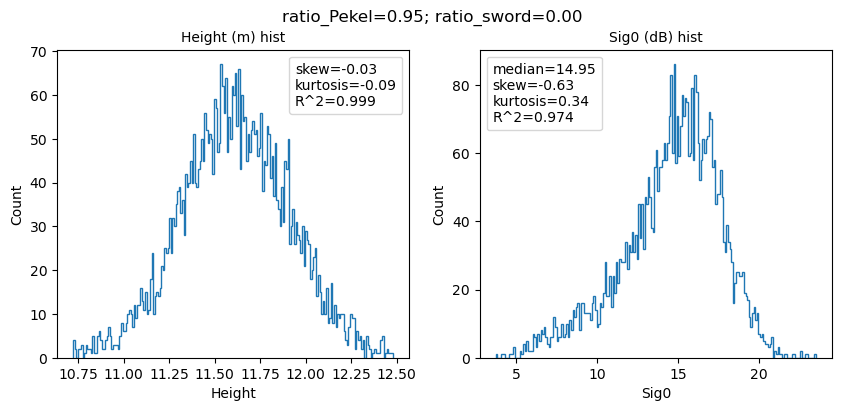

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.49866603129805 -29.964575097062312
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:27:32,919 [INFO] Ratio pekel, ratio sword: 0.9656188605108055, 0.0
2026-02-12 14:27:32,919 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.99778938293457, -0.14322812855243683, -0.44683393836021423, 0.9457056522369385, -0.700810432434082, 0.9883101505778908, 0.9653636897462188


Body type: WATER
Bathtub ring method is applied

Processing Label 12 / 18


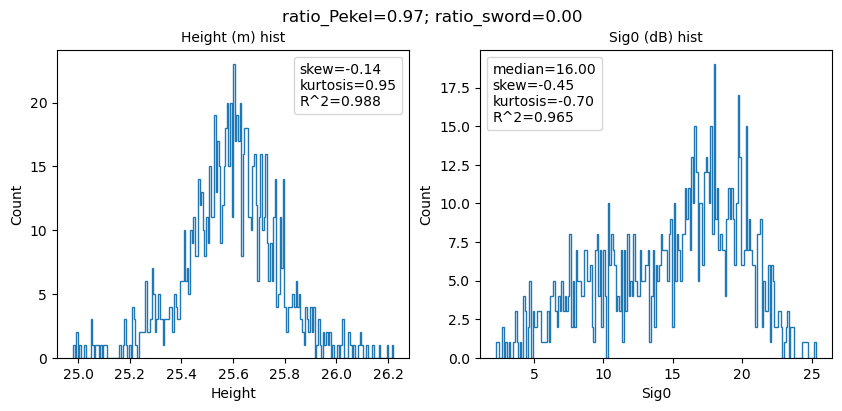

2026-02-12 14:27:33,162 [INFO] Ratio pekel, ratio sword: 0.9941520467836257, 0.0
2026-02-12 14:27:33,163 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.297943115234375, 0.014322398230433464, -0.5698335766792297, 0.4033839702606201, -0.2956674098968506, 0.9965309816860571, 0.967640363023819


Body type: WATER
Bathtub ring method is applied

Processing Label 13 / 18


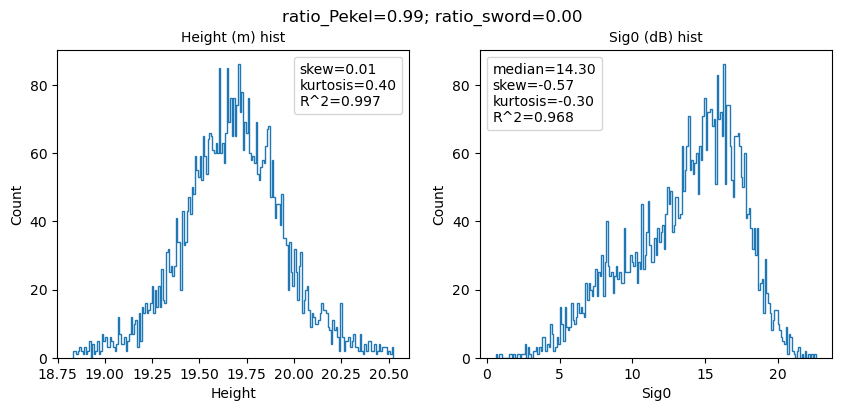

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.545636375030767 -30.000459378227184
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:27:33,426 [INFO] Ratio pekel, ratio sword: 0.9789983844911146, 0.0
2026-02-12 14:27:33,426 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.53453254699707, 0.303086519241333, -0.05014152079820633, 0.48041772842407227, -1.0573347806930542, 0.9905927272573287, 0.972995556454717


Body type: WATER
Bathtub ring method is applied

Processing Label 14 / 18


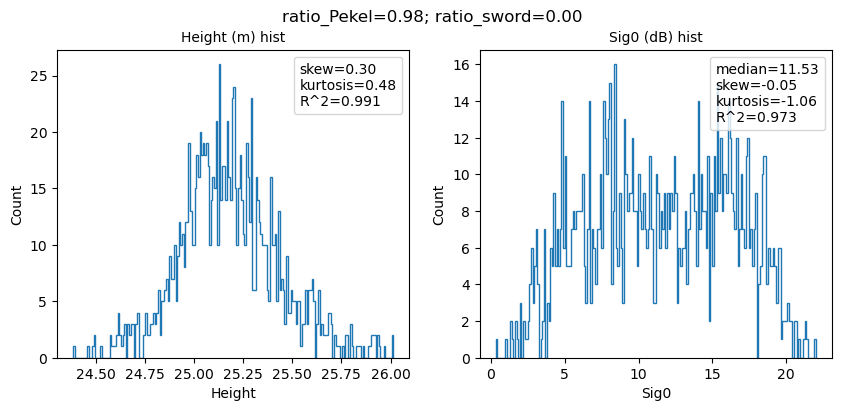

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.639895509853801 -30.01831990175344
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:27:33,910 [INFO] Ratio pekel, ratio sword: 0.9291736930860034, 0.0
2026-02-12 14:27:33,911 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.794804573059082, 0.020781638100743294, -0.5402011871337891, 0.5375139713287354, -0.12184643745422363, 0.9940414485472119, 0.9762321173154972


Body type: WATER
Bathtub ring method is applied

Processing Label 15 / 18


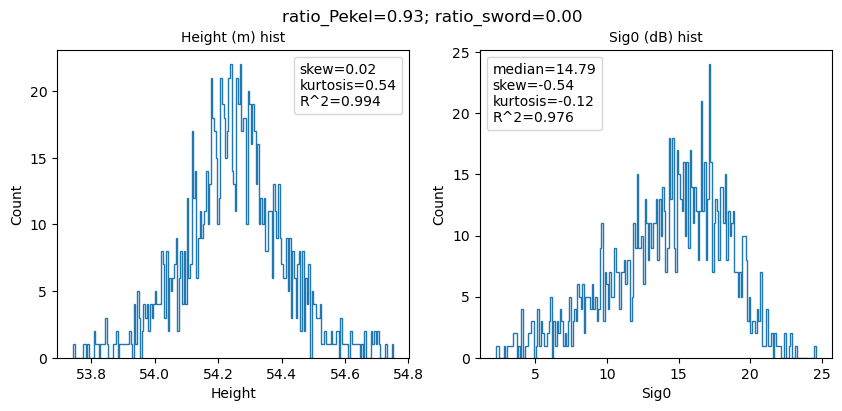

2026-02-12 14:27:34,140 [INFO] Ratio pekel, ratio sword: 0.7978003384094755, 0.0
2026-02-12 14:27:34,141 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.982250213623047, 0.11369219422340393, -0.8545956611633301, 0.21331048011779785, 1.4240970611572266, 0.9967963544993823, 0.9554208382413065


Body type: WATER
Bathtub ring method is applied

Processing Label 16 / 18


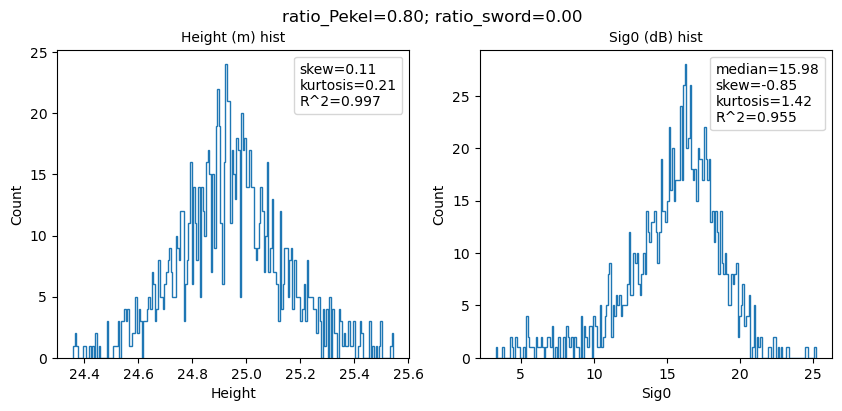

2026-02-12 14:27:34,373 [INFO] Ratio pekel, ratio sword: 0.9446529080675422, 0.0
2026-02-12 14:27:34,373 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.400169372558594, 0.21510618925094604, -1.0569300651550293, 0.4122936725616455, 1.0944666862487793, 0.9942146070809545, 0.9288325390036182


Body type: WATER
Bathtub ring method is applied

Processing Label 17 / 18


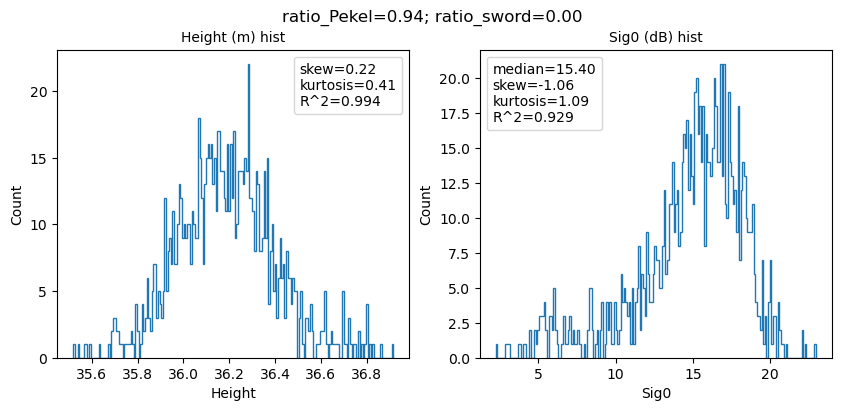

2026-02-12 14:27:34,614 [INFO] Ratio pekel, ratio sword: 0.9855345911949686, 0.0
2026-02-12 14:27:34,614 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.11245346069336, 0.10399773716926575, -0.8350342512130737, 0.13107800483703613, 0.8175942897796631, 0.9983325883572335, 0.9596239396317725


Body type: WATER
Bathtub ring method is applied

Processing Label 18 / 18


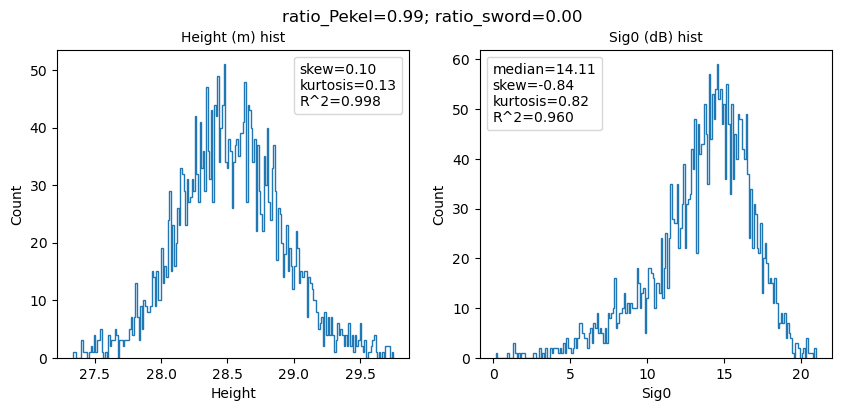

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.44101505067723 -30.092068195013628
  return _ogr.Geometry_IsValid(self, *args)


Body type: WATER
Bathtub ring method is applied


2026-02-12 14:27:57,889 [INFO] Filtering using flags
2026-02-12 14:28:01,053 [INFO] PIXC: /work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Lajeodo/input/pixc/SWOT_L2_HR_PIXC_031_214_207L_20250414T191844_20250414T191855_PIC2_01.nc


Processing PIXC 2/3


2026-02-12 14:28:38,117 [INFO] Extract water points
2026-02-12 14:28:38,204 [INFO] Remove pixels too close to near_range
2026-02-12 14:28:41,017 [INFO] Extract contiguous water points by keeping only water bodies whose area is greater than threshold


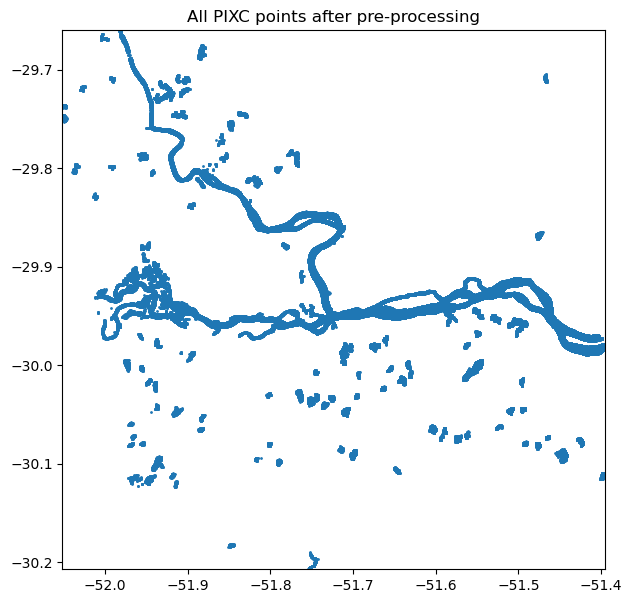

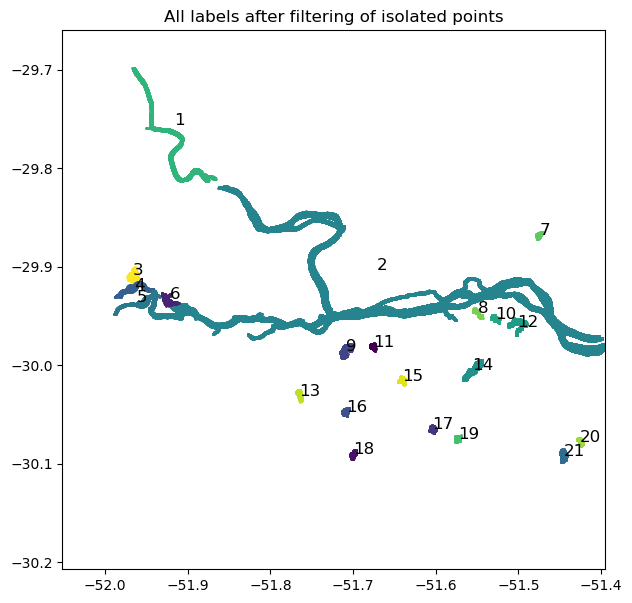

2026-02-12 14:28:48,631 [INFO] Ratio pekel, ratio sword: 0.894409282700422, 0.9919831223628692
2026-02-12 14:28:48,631 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):17.82948875427246, 0.35685253143310547, -0.291382372379303, 0.7187130451202393, 0.5612108707427979, 0.9856351258700222, 0.9924244612924918


Number of water bodies found : 21

Processing Label 1 / 21


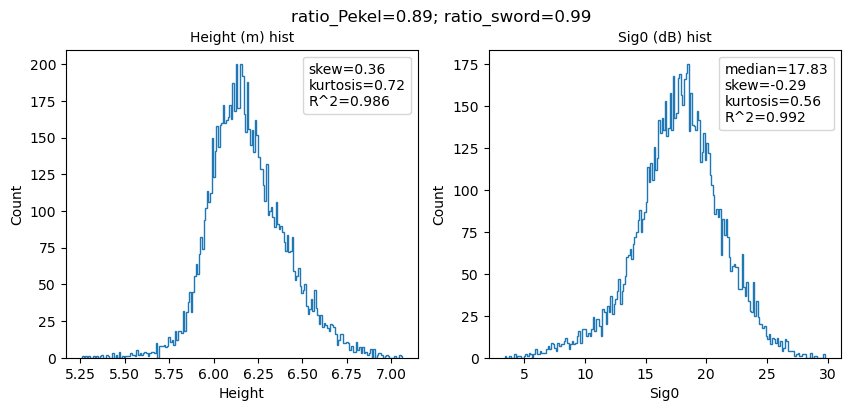

Body type: WATER
Bathtub ring method is applied

Processing Label 2 / 21


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.880415387927577 -29.807943873565112
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:28:49,407 [INFO] Ratio pekel, ratio sword: 0.7275969770354093, 0.6883286475108293
2026-02-12 14:28:49,407 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.302013397216797, -0.5937183499336243, -0.3947252631187439, 0.9610707759857178, 0.4766082763671875, 0.9739467307361297, 0.990567584080496


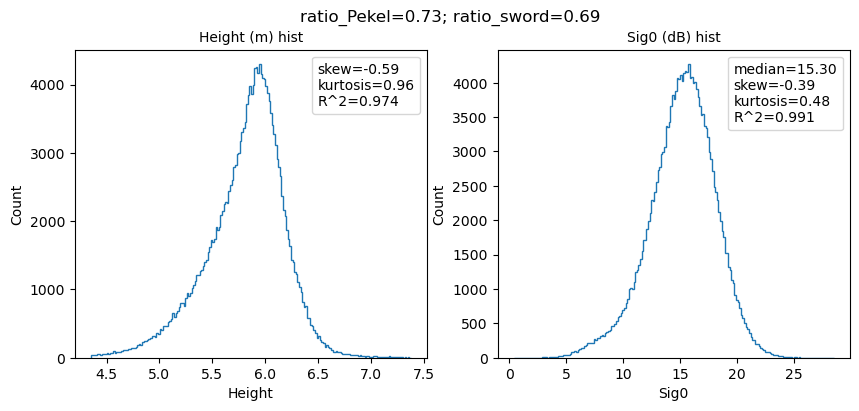

Body type: WATER
Bathtub ring method is applied


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.399354141775163 -29.973217166625322
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:29:03,553 [INFO] Ratio pekel, ratio sword: 0.8269085411942555, 0.0
2026-02-12 14:29:03,554 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):13.741523742675781, -0.626163125038147, -0.3216453492641449, 2.8787035942077637, 0.2570030689239502, 0.9358927309317444, 0.9909892250540543



Processing Label 3 / 21


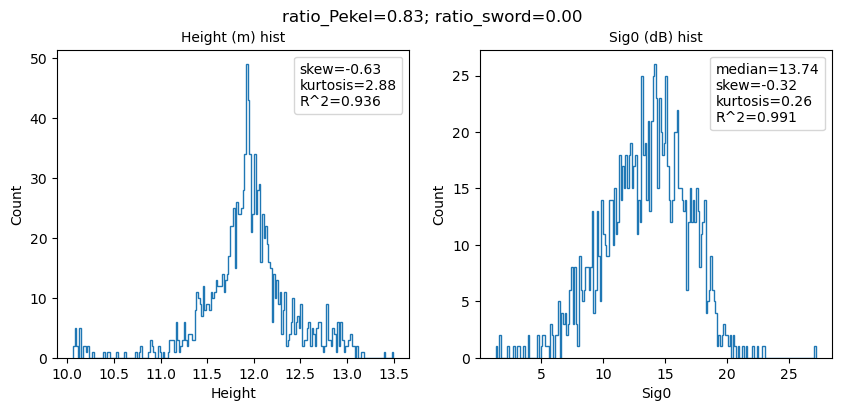

2026-02-12 14:29:03,802 [INFO] Ratio pekel, ratio sword: 0.9144119271120927, 0.04417448923246825
2026-02-12 14:29:03,803 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):18.409725189208984, -0.0123357605189085, 0.1968909204006195, 0.0545039176940918, 0.43563270568847656, 0.9991708131603269, 0.9932691642530576


Body type: WATER
Bathtub ring method is applied

Processing Label 4 / 21


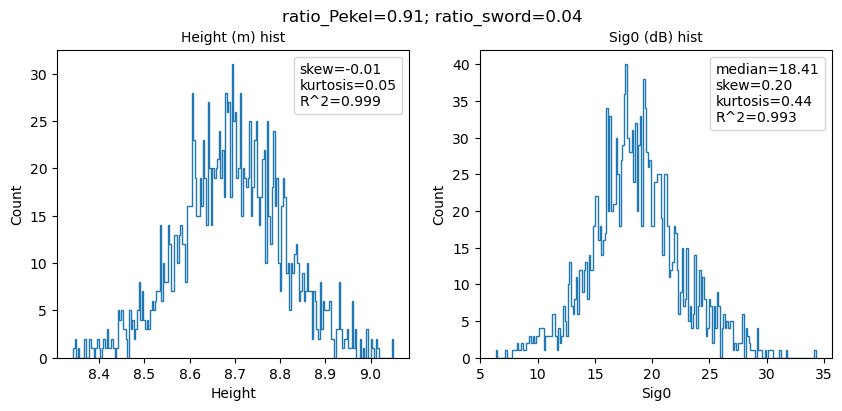

2026-02-12 14:29:04,069 [INFO] Ratio pekel, ratio sword: 0.9213810316139767, 0.4812811980033278
2026-02-12 14:29:04,069 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):18.443758010864258, 0.05330302193760872, -0.1222725585103035, 0.34189462661743164, 0.08053851127624512, 0.9971309528211137, 0.9957720722838357


Body type: WATER
Bathtub ring method is applied

Processing Label 5 / 21


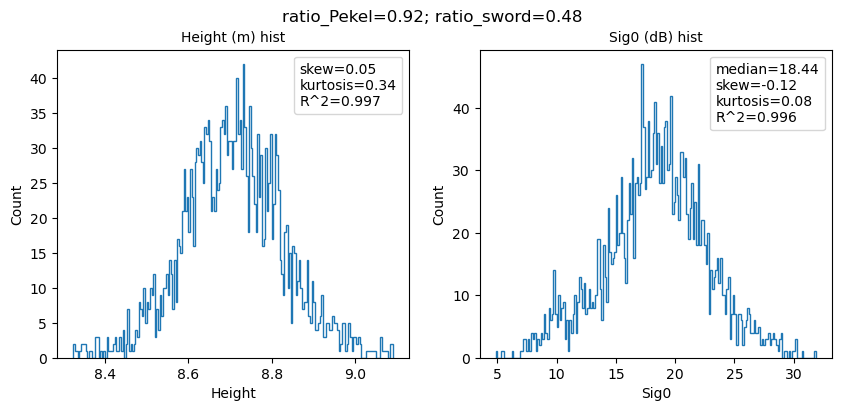

2026-02-12 14:29:04,326 [INFO] Ratio pekel, ratio sword: 0.9833005893909627, 0.0
2026-02-12 14:29:04,327 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):16.159055709838867, 0.10622161626815796, -0.19598716497421265, 0.09022212028503418, -0.39702844619750977, 0.9975641782802837, 0.9817300872475706


Body type: WATER
Bathtub ring method is applied

Processing Label 6 / 21


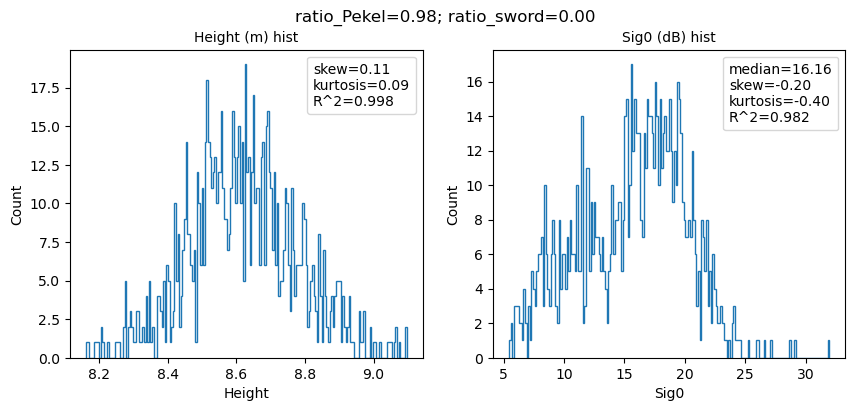

2026-02-12 14:29:04,824 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 14:29:04,825 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.103452682495117, -0.0013416685396805406, -0.5502979755401611, 0.23714494705200195, 0.1797466278076172, 0.998446666575186, 0.9788326560759115


Body type: WATER
Bathtub ring method is applied

Processing Label 7 / 21


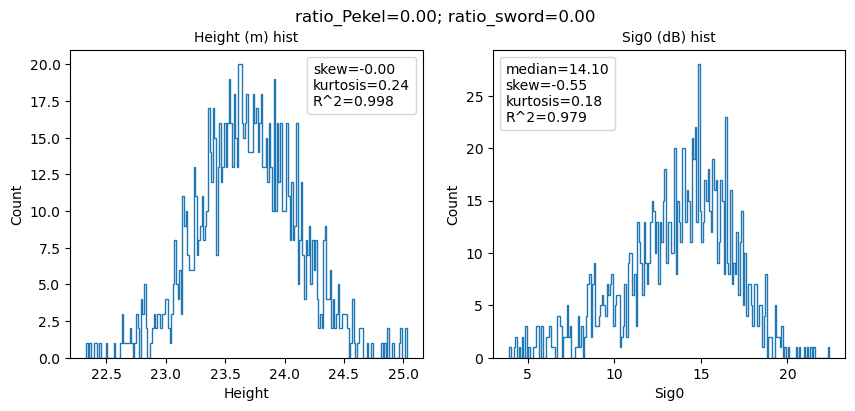

2026-02-12 14:29:05,064 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 14:29:05,064 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.446856498718262, 0.2469043880701065, -0.5889303684234619, 0.1630866527557373, -0.16086316108703613, 0.9941821494617896, 0.9693346213334249


Body type: LAND

Processing Label 8 / 21


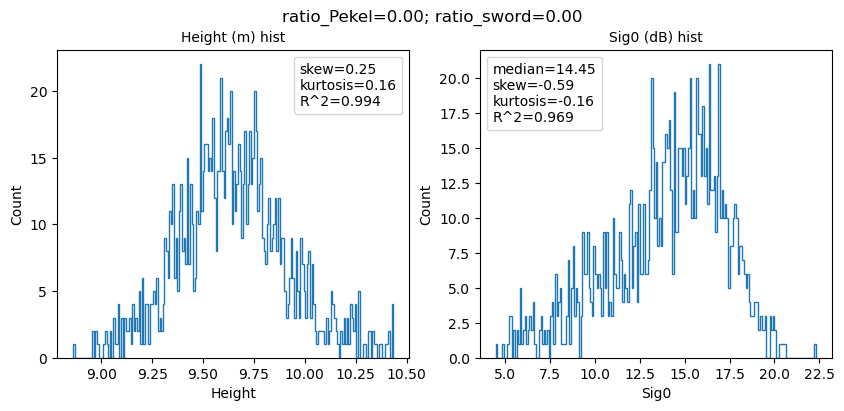

2026-02-12 14:29:05,314 [INFO] Ratio pekel, ratio sword: 0.9721663313212608, 0.0
2026-02-12 14:29:05,314 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.889309883117676, 0.13205942511558533, -1.0292567014694214, 1.1785483360290527, 1.3388748168945312, 0.9864889591951804, 0.938192216890661


Body type: LAND

Processing Label 9 / 21


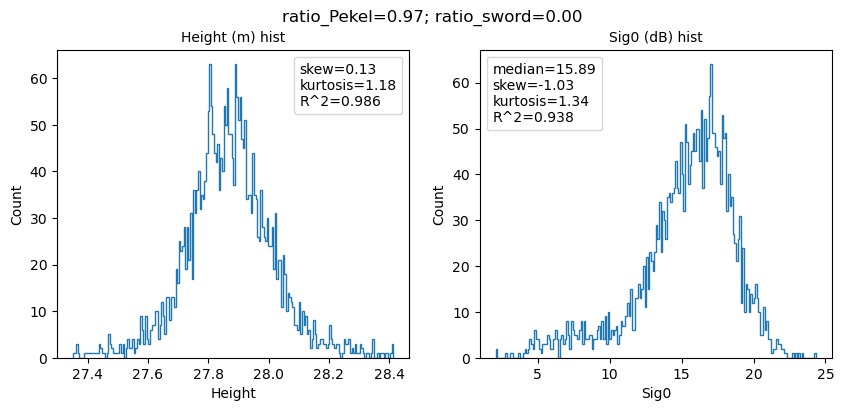

2026-02-12 14:29:05,565 [INFO] Ratio pekel, ratio sword: 0.7946666666666666, 0.0
2026-02-12 14:29:05,566 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.209623336791992, -0.05134599283337593, -0.5039049386978149, -0.17367315292358398, 0.29311633110046387, 0.9983339999904606, 0.982514202250046


Body type: WATER
Bathtub ring method is applied

Processing Label 10 / 21


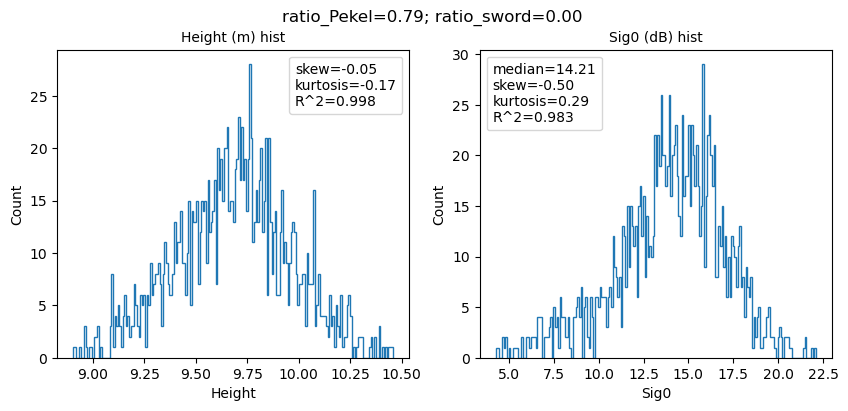

2026-02-12 14:29:05,817 [INFO] Ratio pekel, ratio sword: 0.9056047197640118, 0.0
2026-02-12 14:29:05,818 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):12.37830924987793, 0.14509332180023193, 0.0018447993788868189, 4.660130023956299, -0.5396511554718018, 0.9377087966486533, 0.9944471668092676


Body type: WATER
Bathtub ring method is applied

Processing Label 11 / 21


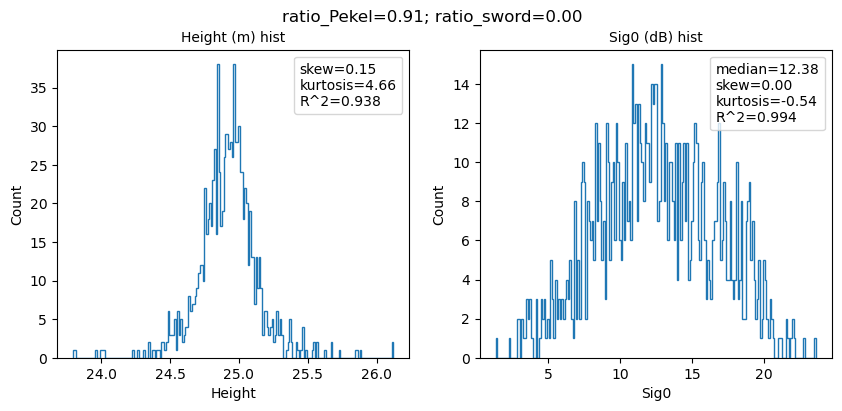

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.673102108401835 -29.982105551393008
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:29:06,069 [INFO] Ratio pekel, ratio sword: 0.9439387670666115, 0.0
2026-02-12 14:29:06,069 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.476099014282227, -0.03665342926979065, -0.5590190887451172, -0.025687217712402344, 0.39604759216308594, 0.9983219778495087, 0.9811677124345827


Body type: WATER
Bathtub ring method is applied

Processing Label 12 / 21


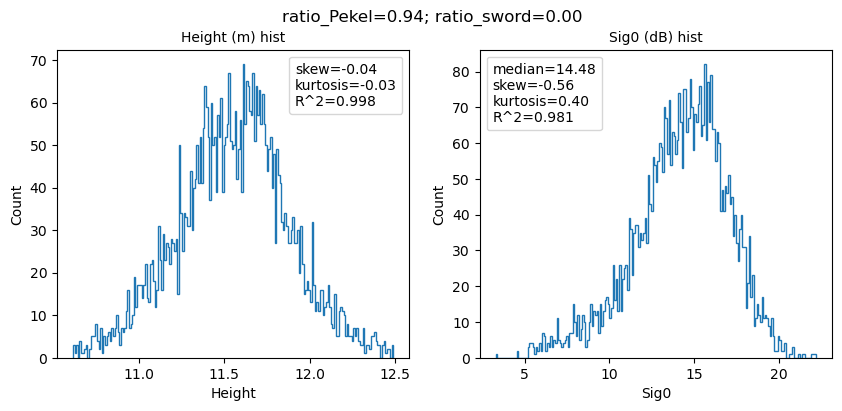

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.511614114086505 -29.9574392019607
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:29:06,340 [INFO] Ratio pekel, ratio sword: 0.9731481481481481, 0.0
2026-02-12 14:29:06,340 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.196662902832031, 0.07785669714212418, -0.44939571619033813, 0.7297844886779785, -0.5705585479736328, 0.9896937221310327, 0.9682148339163857


Body type: WATER
Bathtub ring method is applied

Processing Label 13 / 21


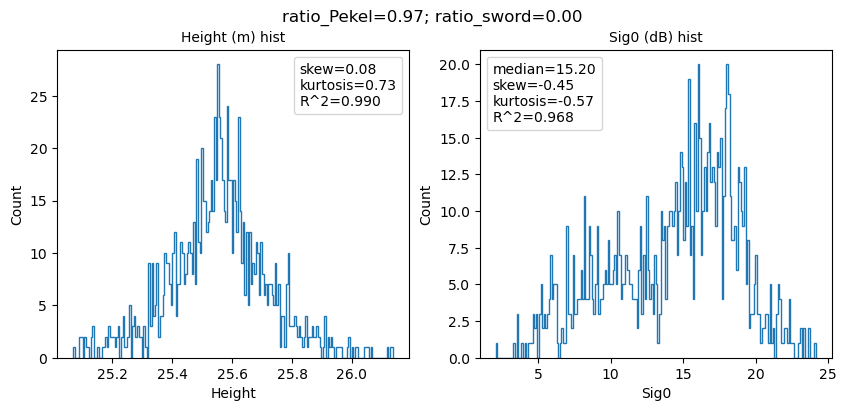

2026-02-12 14:29:06,589 [INFO] Ratio pekel, ratio sword: 0.9940108553247239, 0.0
2026-02-12 14:29:06,590 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.797855377197266, 0.045519884675741196, -0.5779884457588196, 0.4483208656311035, -0.2773468494415283, 0.9959955969126386, 0.966807262052378


Body type: WATER
Bathtub ring method is applied

Processing Label 14 / 21


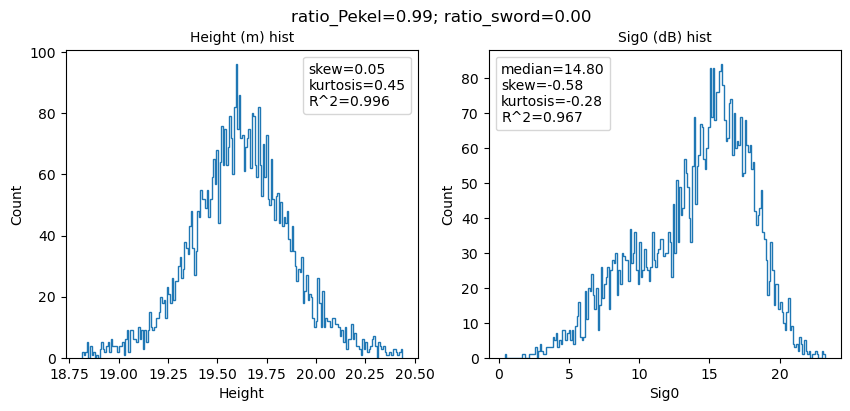

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.559184643923615 -30.010000605207349
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:29:06,864 [INFO] Ratio pekel, ratio sword: 0.9710884353741497, 0.0
2026-02-12 14:29:06,865 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):13.146001815795898, 0.27274927496910095, -0.2558651864528656, 0.607459306716919, -1.0662418603897095, 0.9891232782409443, 0.9605006895940603


Body type: WATER
Bathtub ring method is applied

Processing Label 15 / 21


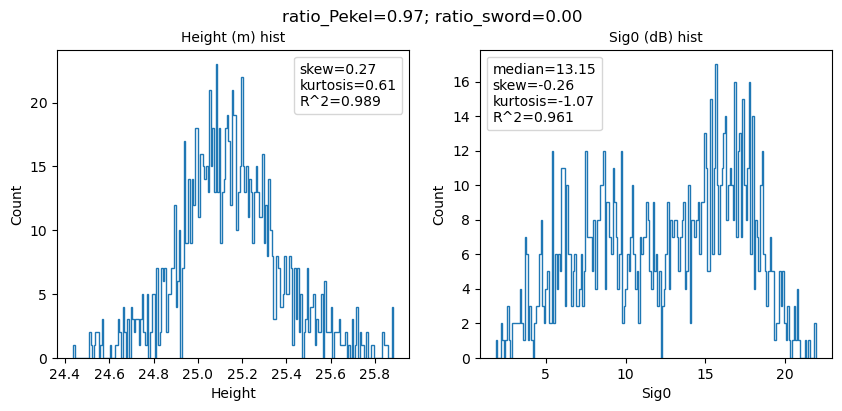

2026-02-12 14:29:07,111 [INFO] Ratio pekel, ratio sword: 0.9528301886792453, 0.0
2026-02-12 14:29:07,111 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.056808471679688, 0.09739316999912262, -0.368844598531723, 0.4333326816558838, -0.3738572597503662, 0.9945579121254099, 0.984514619732058


Body type: WATER
Bathtub ring method is applied

Processing Label 16 / 21


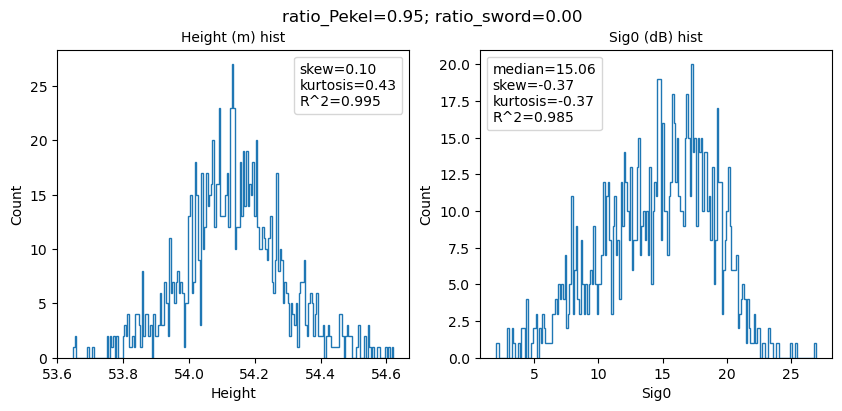

2026-02-12 14:29:07,352 [INFO] Ratio pekel, ratio sword: 0.75518341307815, 0.0
2026-02-12 14:29:07,353 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.459125518798828, 0.10584323108196259, -0.6778256297111511, -0.11128830909729004, 0.6689579486846924, 0.9977770624244892, 0.9719537603176904


Body type: WATER
Bathtub ring method is applied

Processing Label 17 / 21


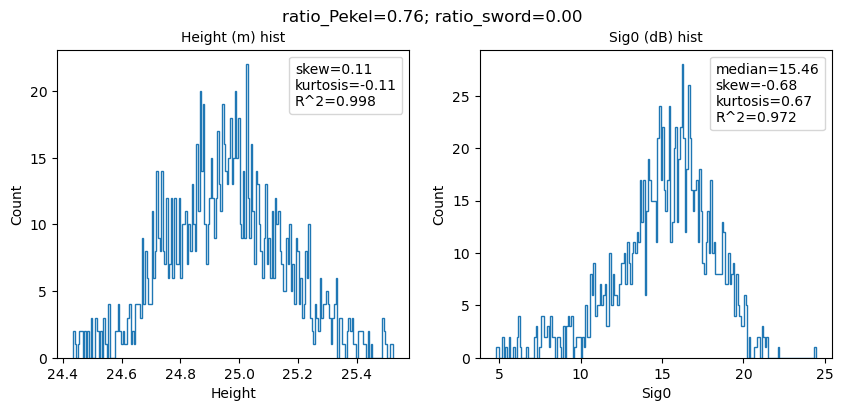

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.600815429537022 -30.065787765036184
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:29:07,583 [INFO] Ratio pekel, ratio sword: 0.12716763005780346, 0.0
2026-02-12 14:29:07,584 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):16.61069679260254, 0.004675137344747782, -0.9938693642616272, -0.40591931343078613, 1.4805450439453125, 0.9964886473048353, 0.9442959456417647


Body type: WATER
Bathtub ring method is applied

Processing Label 18 / 21


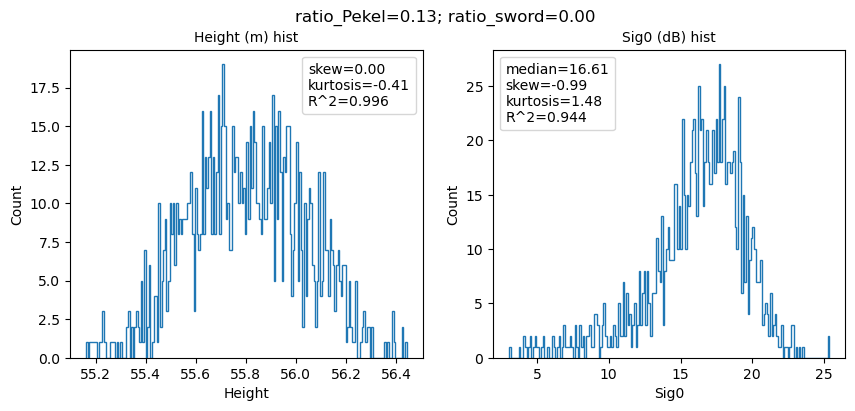

2026-02-12 14:29:07,830 [INFO] Ratio pekel, ratio sword: 0.9449781659388646, 0.0
2026-02-12 14:29:07,830 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.265036582946777, 0.17069819569587708, -1.0093238353729248, 0.33621740341186523, 0.6551141738891602, 0.9957445554103821, 0.9251894013310169


Body type: LAND

Processing Label 19 / 21


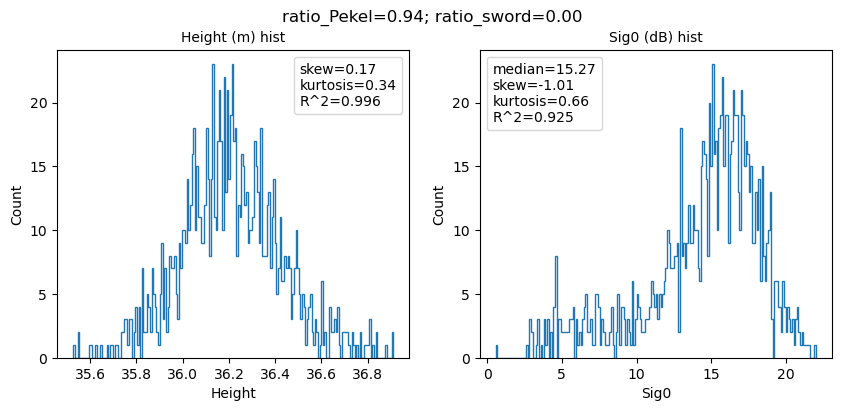

2026-02-12 14:29:08,060 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 14:29:08,061 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.331579208374023, -0.1322115659713745, -0.3862009644508362, -0.06380224227905273, -0.035635948181152344, 0.997892142521588, 0.9892722729036099


Body type: WATER
Bathtub ring method is applied

Processing Label 20 / 21


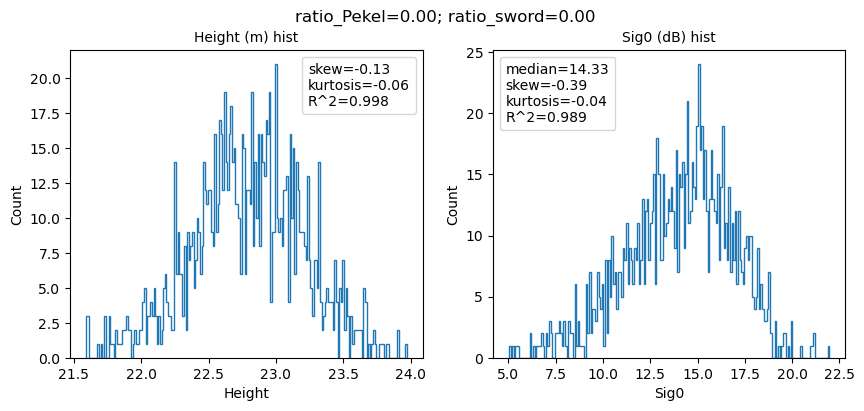

2026-02-12 14:29:08,307 [INFO] Ratio pekel, ratio sword: 0.9876394332227917, 0.0
2026-02-12 14:29:08,308 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.67367935180664, 0.04001978412270546, -0.618087649345398, -0.07164645195007324, 0.5713012218475342, 0.9991768602786245, 0.9779837675075258


Body type: LAND

Processing Label 21 / 21


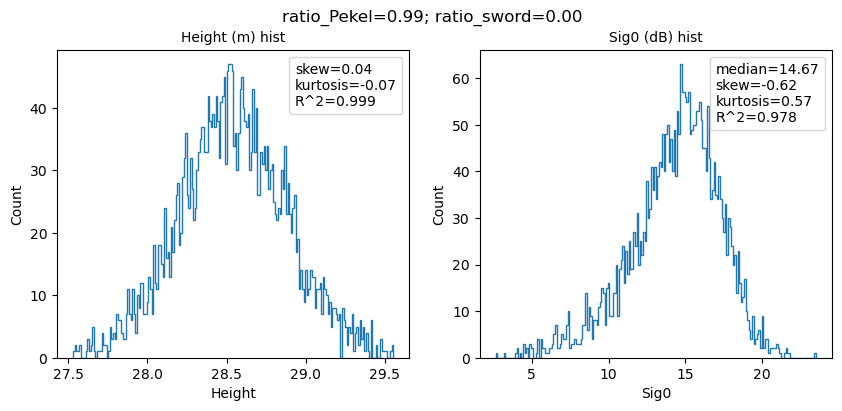

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.44263004685638 -30.095612372701009
  return _ogr.Geometry_IsValid(self, *args)


Body type: WATER
Bathtub ring method is applied


2026-02-12 14:29:36,128 [INFO] Filtering using flags
2026-02-12 14:29:39,757 [INFO] PIXC: /work/SWOT/swotdev/swotdev/stephag/floodplain/run/testcase_Lajeodo/input/pixc/SWOT_L2_HR_PIXC_032_214_207L_20250505T160348_20250505T160359_PIC2_01.nc


Processing PIXC 3/3


2026-02-12 14:30:09,370 [INFO] Extract water points
2026-02-12 14:30:09,435 [INFO] Remove pixels too close to near_range
2026-02-12 14:30:12,079 [INFO] Extract contiguous water points by keeping only water bodies whose area is greater than threshold


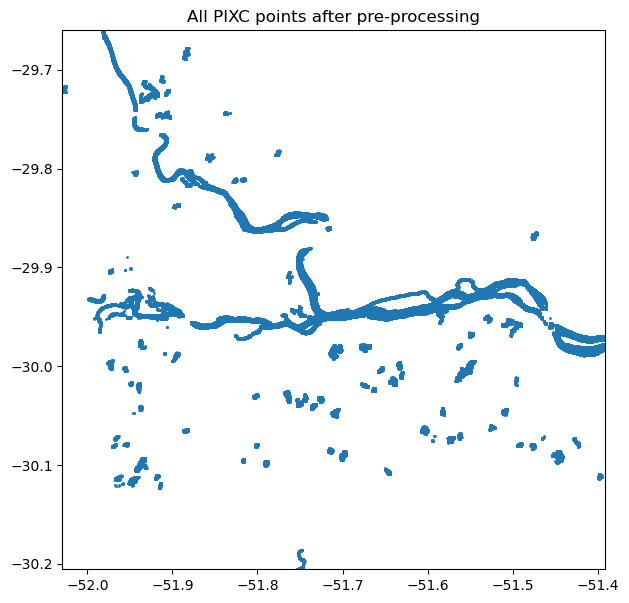

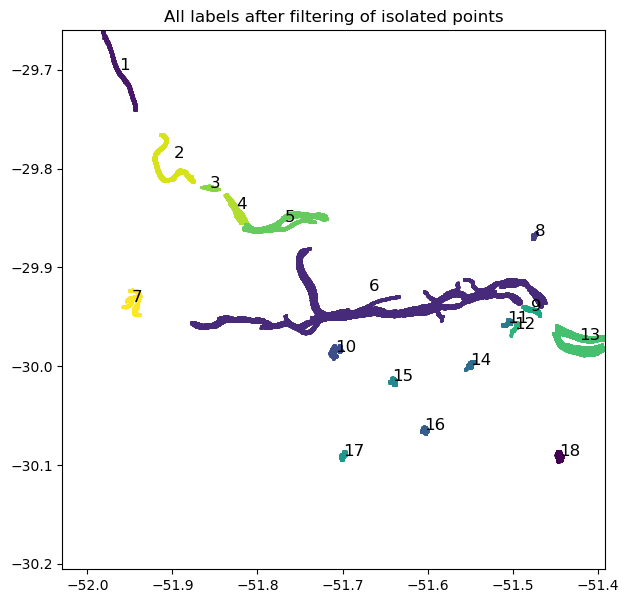

2026-02-12 14:30:18,635 [INFO] Ratio pekel, ratio sword: 0.8831285585855558, 0.9961042852861852
2026-02-12 14:30:18,635 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):19.494049072265625, 0.11581720411777496, -0.4170824885368347, 0.4322245121002197, 0.2444899082183838, 0.9946623019020688, 0.9868674152824779


Number of water bodies found : 18

Processing Label 1 / 18


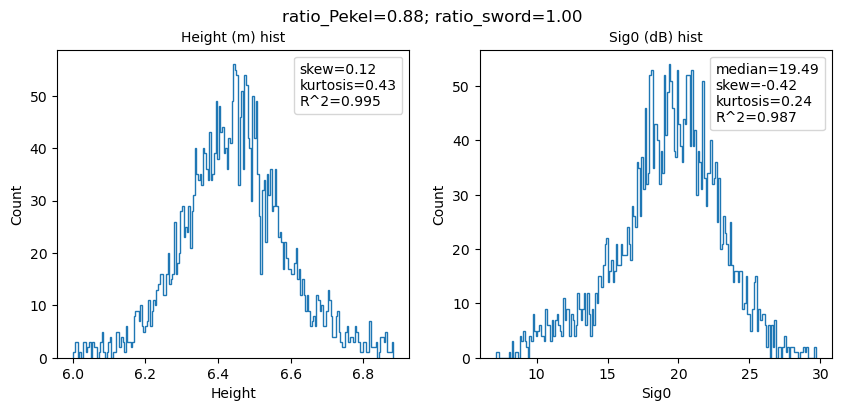

2026-02-12 14:30:18,901 [INFO] Ratio pekel, ratio sword: 0.892020725388601, 0.9983419689119171
2026-02-12 14:30:18,901 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):19.92894744873047, 0.31842395663261414, -0.5853846669197083, 1.998471736907959, 0.4700510501861572, 0.9720101308025608, 0.9718606119942614


Body type: WATER
Bathtub ring method is applied

Processing Label 2 / 18


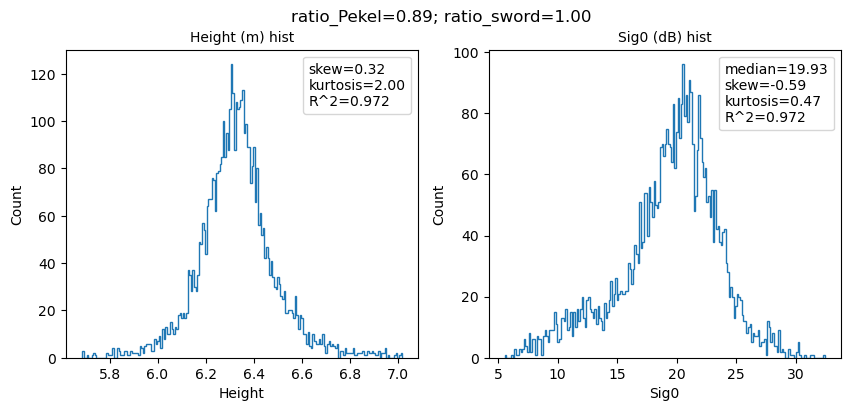

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.894205640813389 -29.801993791417203
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:30:19,179 [INFO] Ratio pekel, ratio sword: 0.8870813397129187, 1.0
2026-02-12 14:30:19,180 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):21.651456832885742, -0.20239000022411346, -0.28905975818634033, 0.38335490226745605, 0.7547397613525391, 0.9947827392505129, 0.9861057805775867


Body type: WATER
Bathtub ring method is applied

Processing Label 3 / 18


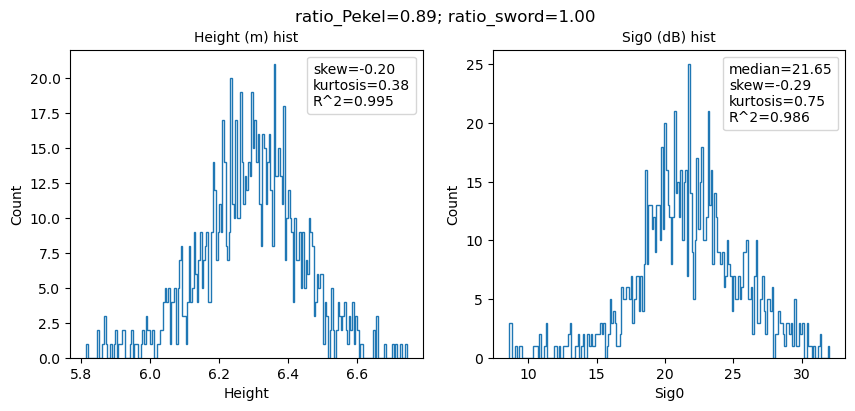

2026-02-12 14:30:19,427 [INFO] Ratio pekel, ratio sword: 0.9102405157451029, 1.0
2026-02-12 14:30:19,428 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):19.027191162109375, 0.0870564877986908, -0.9140596389770508, 0.7600469589233398, 1.4057531356811523, 0.9932537684110417, 0.9528138167659632


Body type: WATER
Bathtub ring method is applied

Processing Label 4 / 18


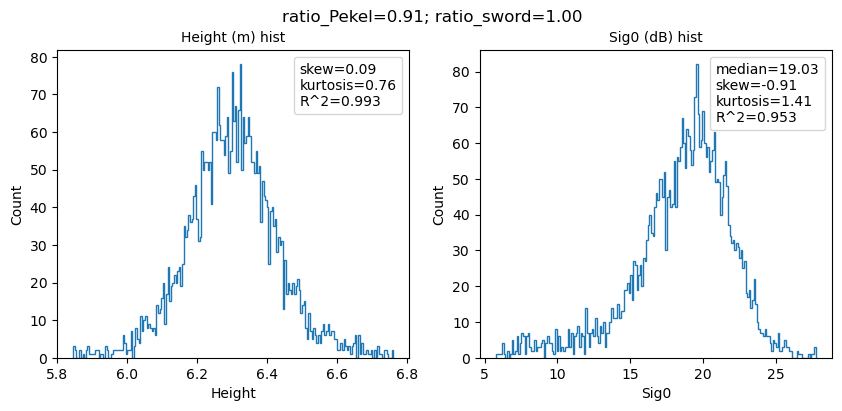

2026-02-12 14:30:19,710 [INFO] Ratio pekel, ratio sword: 0.9726524685382382, 0.9630525976121329
2026-02-12 14:30:19,710 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):18.347713470458984, 0.03144431859254837, -0.5102781653404236, 0.7457900047302246, 0.4209890365600586, 0.9939198132348838, 0.9803801916012811


Body type: WATER
Bathtub ring method is applied

Processing Label 5 / 18


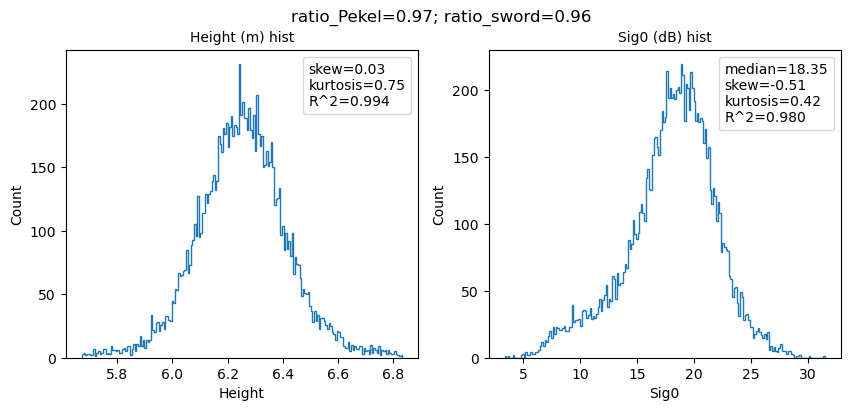

Body type: WATER
Bathtub ring method is applied

Processing Label 6 / 18


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.744670078276862 -29.845104740769571
  return _ogr.Geometry_IsValid(self, *args)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 14:30:20,279 [INFO] Ratio pekel, ratio sword: 0.9126134131512487, 0.895905434477598
2026-02-12 14:30:20,280 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):17.07065773010254, -0.4125328063964844, -0.35481035709381104, 0.647777795791626, 0.17583417892456055, 0.9842105659265095, 0.9893448677526404


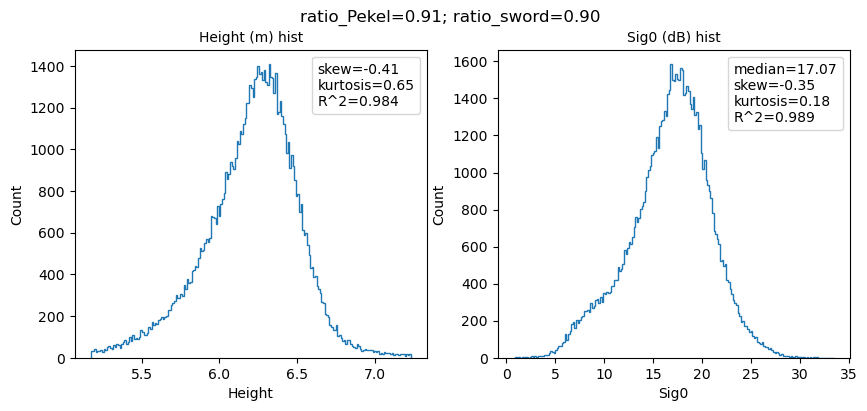

Body type: WATER
Bathtub ring method is applied


/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.483388716367386 -29.917517694345651
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:30:26,315 [INFO] Ratio pekel, ratio sword: 0.9224004138644594, 0.7087428867046043
2026-02-12 14:30:26,315 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):21.560361862182617, 0.2776678800582886, -0.34538695216178894, 1.0001959800720215, -0.004225492477416992, 0.9860414845599781, 0.9871587740430121



Processing Label 7 / 18


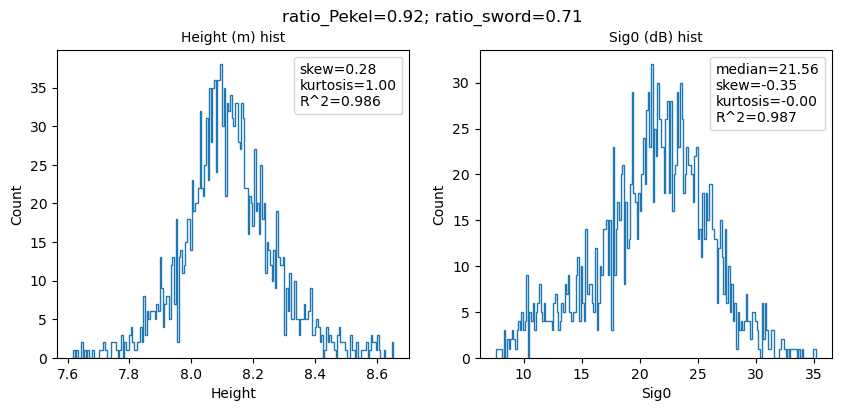

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.942676055578538 -29.936339819633709
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:30:26,572 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 14:30:26,573 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):13.035938262939453, -0.11656536161899567, -0.09201838076114655, -0.25987744331359863, -0.045400142669677734, 0.9972074686400447, 0.998288287194916


Body type: WATER
Bathtub ring method is applied

Processing Label 8 / 18


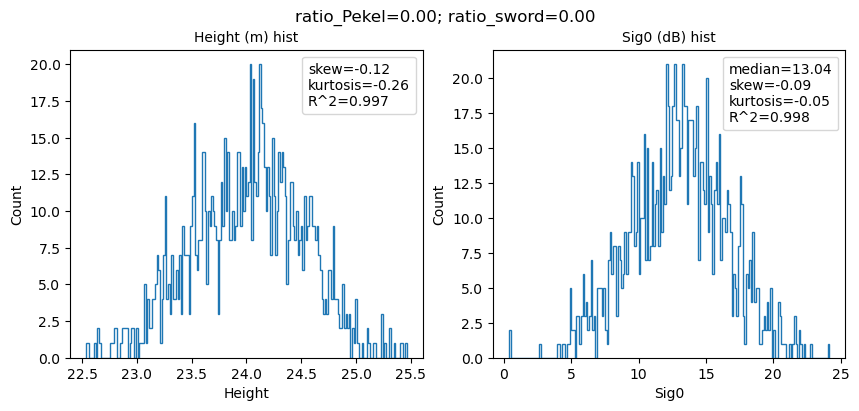

2026-02-12 14:30:26,827 [INFO] Ratio pekel, ratio sword: 0.9257362355953905, 0.6645326504481434
2026-02-12 14:30:26,828 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):16.88772201538086, 0.16002719104290009, -0.8584252595901489, 0.5881531238555908, 0.5056188106536865, 0.9939259562277124, 0.9492977089562373


Body type: LAND

Processing Label 9 / 18


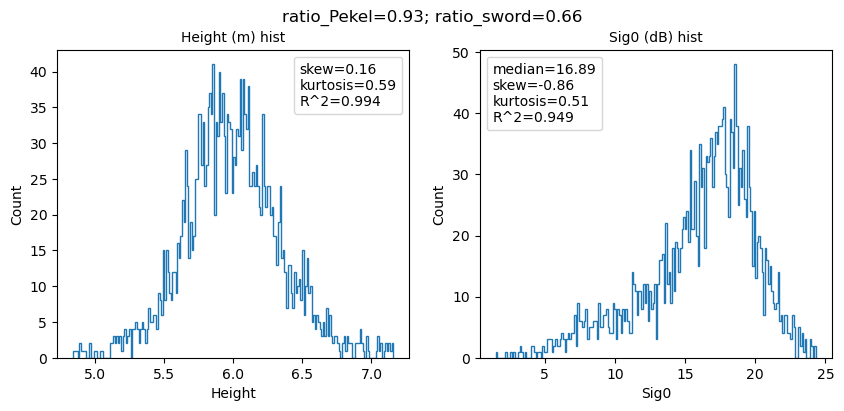

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.483647906642915 -29.942321149831102
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:30:27,085 [INFO] Ratio pekel, ratio sword: 0.9623098201936376, 0.0
2026-02-12 14:30:27,086 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):16.056211471557617, 0.40228262543678284, -0.6311383247375488, 1.7934532165527344, -0.33816027641296387, 0.9723653115208266, 0.956855055860437


Body type: WATER
Bathtub ring method is applied

Processing Label 10 / 18


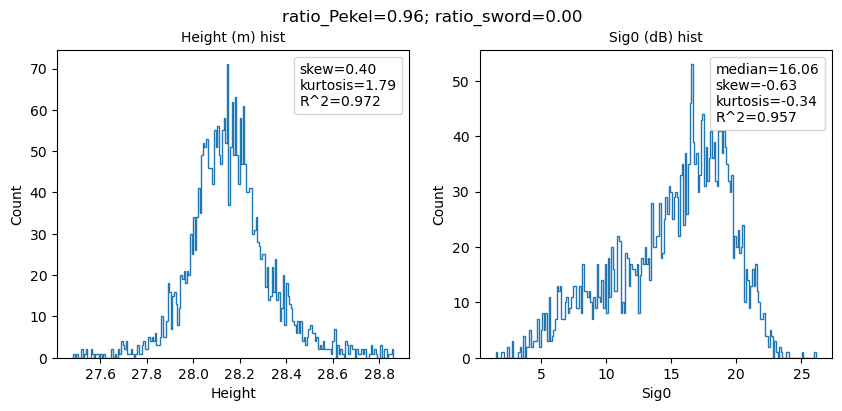

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.709528855813396 -29.978788838406235
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:30:27,340 [INFO] Ratio pekel, ratio sword: 0.9963235294117647, 0.0
2026-02-12 14:30:27,340 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):13.128105163574219, -0.027184220030903816, -0.20496177673339844, -0.0371549129486084, -0.281231164932251, 0.998671041511014, 0.9948767333728687


Body type: WATER
Bathtub ring method is applied

Processing Label 11 / 18


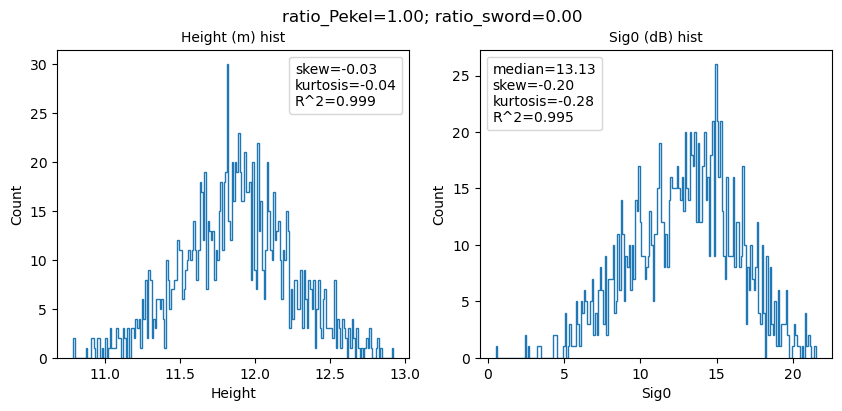

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.507763429484385 -29.956741640865719
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:30:27,580 [INFO] Ratio pekel, ratio sword: 0.956661316211878, 0.0
2026-02-12 14:30:27,580 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):12.181878089904785, 0.14263863861560822, -0.013546387664973736, -0.14873790740966797, -0.3215465545654297, 0.9970626806759336, 0.9963780583488054


Body type: WATER
Bathtub ring method is applied

Processing Label 12 / 18


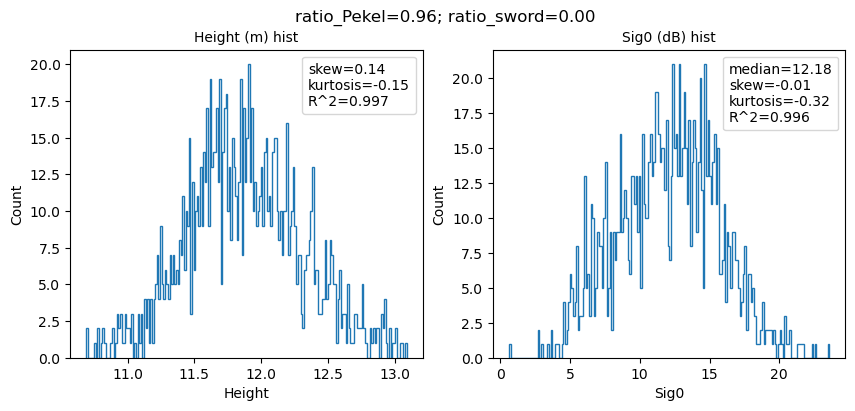

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.501234701819193 -29.964636583802552
  return _ogr.Geometry_IsValid(self, *args)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/water_or_land.py:184: RuntimeWarning: invalid value encountered in log10
  sig0 = np.where(sig0 > 0, 10 * np.log10(sig0), -1e6)
2026-02-12 14:30:27,863 [INFO] Ratio pekel, ratio sword: 0.0, 0.0
2026-02-12 14:30:27,863 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):15.576398849487305, -0.01906377263367176, -0.6141442060470581, -0.08015275001525879, 0.6239137649536133, 0.9992421324545451, 0.9795522726704512


Body type: WATER
Bathtub ring method is applied

Processing Label 13 / 18


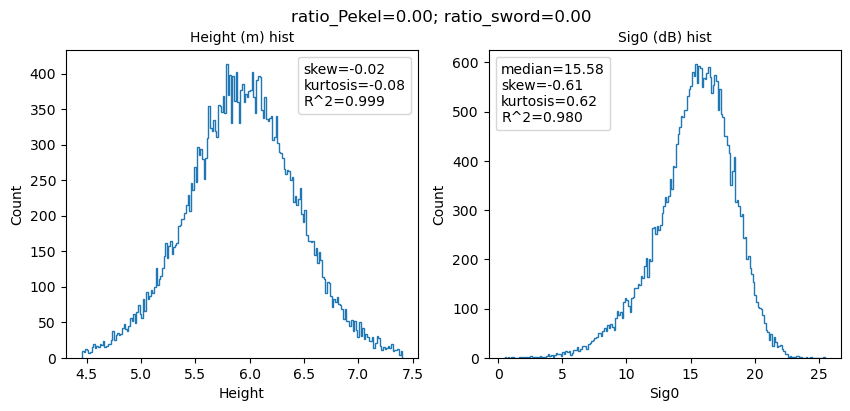

2026-02-12 14:30:28,109 [INFO] Ratio pekel, ratio sword: 0.9984627209838586, 0.0
2026-02-12 14:30:28,109 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):14.815069198608398, -0.06536528468132019, -0.25445517897605896, 0.19283485412597656, 0.09357833862304688, 0.9968638014801509, 0.9945024927097106


Body type: LAND

Processing Label 14 / 18


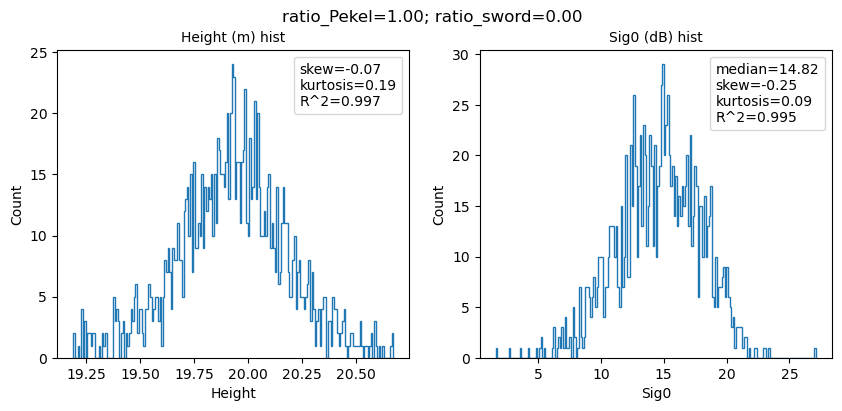

2026-02-12 14:30:28,348 [INFO] Ratio pekel, ratio sword: 0.9713080168776371, 0.0
2026-02-12 14:30:28,348 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):11.581143379211426, -0.24697351455688477, 0.029178565368056297, 0.5698020458221436, -1.1887779235839844, 0.9890662862653753, 0.9600093252322771


Body type: WATER
Bathtub ring method is applied

Processing Label 15 / 18


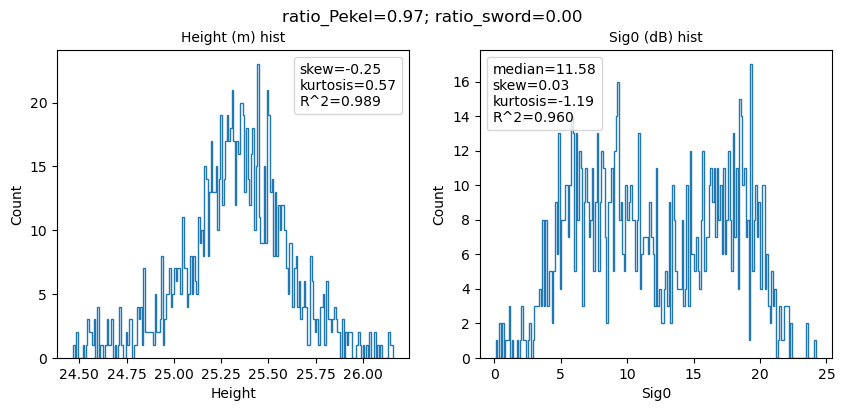

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.644886506632524 -30.015162687053802
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:30:28,596 [INFO] Ratio pekel, ratio sword: 0.7504132231404959, 0.0
2026-02-12 14:30:28,596 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):16.36640167236328, 0.10724341869354248, -0.9815747141838074, 0.2800564765930176, 0.985598087310791, 0.9962651489862195, 0.9406888220220574


Body type: WATER
Bathtub ring method is applied

Processing Label 16 / 18


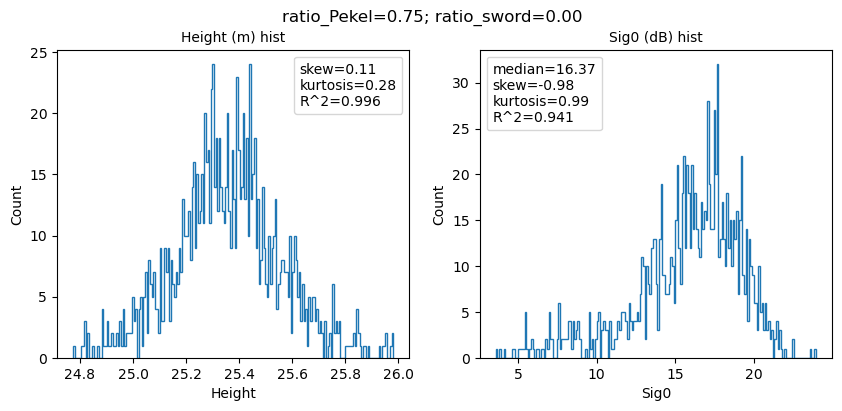

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.605698174173398 -30.061565402417774
  return _ogr.Geometry_IsValid(self, *args)
2026-02-12 14:30:28,831 [INFO] Ratio pekel, ratio sword: 0.1364877161055505, 0.0
2026-02-12 14:30:28,831 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):18.71505355834961, 0.29096657037734985, -0.9936175346374512, -0.4664907455444336, 1.3573970794677734, 0.9877161011973783, 0.9422229918086774


Body type: WATER
Bathtub ring method is applied

Processing Label 17 / 18


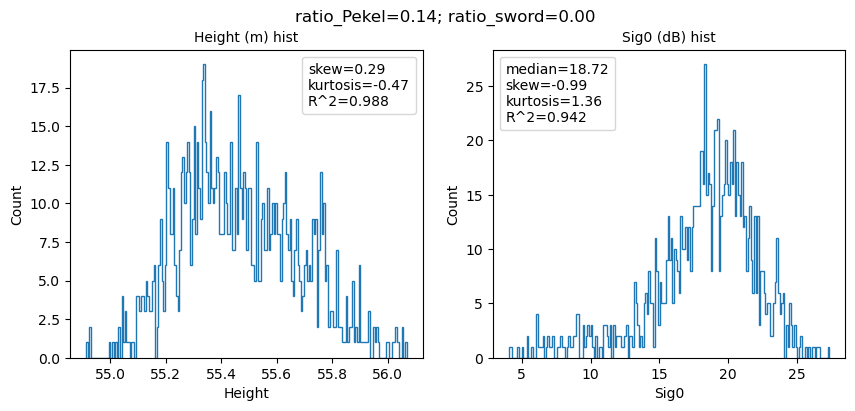

2026-02-12 14:30:29,072 [INFO] Ratio pekel, ratio sword: 0.9797678275290216, 0.0
2026-02-12 14:30:29,073 [INFO] Normality parameters (median_sig0, skew_h, skew_sig0, kurtosis_h, kurtosis_sig0, R²_h, R²_sig0):16.98354148864746, 0.064808689057827, -0.8088652491569519, 0.24715614318847656, 0.771946907043457, 0.9978150556715462, 0.9600623392367094


Body type: WATER
Bathtub ring method is applied

Processing Label 18 / 18


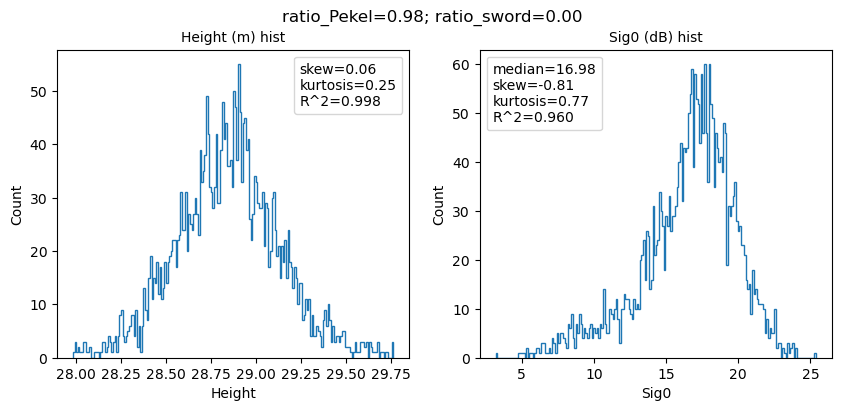

/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/osgeo/ogr.py:5960: RuntimeWarning: Self-intersection at or near point -51.447220101946563 -30.096752058578033
  return _ogr.Geometry_IsValid(self, *args)


Body type: WATER
Bathtub ring method is applied


2026-02-12 14:30:50,951 [INFO] Filtering using flags


In [11]:
# Load class FloodPlain, necessary for access to bathtub ring subroutine
fpdem = Floodplain(None)

# Initialize main FPDEM dataframe
fpdem_land = pd.DataFrame()

# Loop over all PIXC files
for ip, pixc_file in enumerate(inputpixcfiles):
    
    print(f"Processing PIXC {ip+1}/{len(inputpixcfiles)}")
    
    cycle = os.path.basename(pixc_file)[16:19]
    if os.path.isdir(os.path.join(output_dir, f'cycle{cycle}')) is False:
        os.mkdir(os.path.join(output_dir, f'cycle{cycle}'))
    
    # Get PIXCVec file (currently not used at all -- commented lines in floodplain/io/nc.py)
    vec_file = inputvecfiles[ip]
    # Load PixcReader class, and read pixc file
    pixc_reader = PixcReader(polygon_mask, pixc_file, vec_file)

    # Pre-processing of PIXC: extract water points (classification > 2), exclude near-range points, 
    # and clusters whose area is smaller than the given threshold
    water, min_range_ind_to_remove = pre_processing_pixc(pixc_reader, 
                                                         cross_track_min, threshold, 
                                                         sig0_qual)

    # Select only points of classification 3, 4 and some 5 if in Pekel mask 95%-100%,
    # remove all isolated points if some remains in pre-processing,
    # and define clusters / label the detected water bodies
    label_tab, count, classification_tab, \
               height_tab, sig0_tab, \
               azimuth_index_tab, range_index_tab, \
               latitude_tab, \
               longitude_tab = compute_label_and_remove_small_object(water,
                                                                     pixc_reader.range_size, pixc_reader.azimuth_size,
                                                                     pekel_X_100_poly,
                                                                     body_min_size, body_connectivity, 
                                                                     plot=plot, outpath=output_dir, cycle=cycle)
    print(f"Number of water bodies found : {count}")
    
    # Initialize selected PIXC FPDEM dataframe
    fpdem_land_pixc = pd.DataFrame()
    
    # Loop over all detected water bodies in the PIXC
    for label in range(1, count+1):
        
        print(f"\nProcessing Label {label} / {count}")
        
        # Return water_extract (-> GeoDataFrame), only points corresponding to the processed label
        water_extract = compute_subwater_extract_from_label(water, label_tab, 
                                                            azimuth_index_tab, range_index_tab, label)
        if len(water_extract) == 0:
            continue
        
        if approach == 'mixed':
            # TODO: Delete once the new PIXC products have corrected dark_water elevation
            #       At the moment the dark water height is too bad to be used in categorization of bodies
            # This geodataframe is used to parametrize the water body and select its type (land, water or land_water)
            water_extractCateg = water_extract[(water_extract.classification == 3) | 
                                               (water_extract.classification == 4)]
            if len(water_extractCateg) == 0:
                continue
                
            # Plot height and sig0
            if plot == 'yes':
                height_to_plot = np.where(label_tab == label, height_tab, 0)[l0:l1, c0:c1]
                height_to_plot[np.where(height_to_plot == 0)] = np.nan
                sig_to_plot = 10*np.log10(np.where(label_tab == label, sig0_tab, 0)[l0:l1, c0:c1])
                sig_to_plot[np.where(sig_to_plot == 0)] = np.nan
                fig, (ax, ax2) = plt.subplots(nrows=1, ncols=2, layout='constrained')
                ax.set_title("Height(m) for cycle: " + cycle + "-- label: " + str(label))
                im = ax.imshow(height_to_plot)
                fig.colorbar(im, shrink=0.5, ax=ax)
                ax2.set_title("Sig0 (dB)")
                im2 = ax2.imshow(sig_to_plot)
                fig.colorbar(im2, shrink=0.5, ax=ax2)
                plt.show()

            # Find the category the water body belongs to
            water_body_type, categ_params = find_body_category(water_extractCateg, pekel_0_100_poly, poly_sword, plot=plot)
            print(f"Body type: {water_body_type}")

            # Apply different method depending on body category
            # LAND => direct extraction
            # WATER => Bathtub ring method
            # WATER_LAND => clustering method
            #         LAND => direct extraction
            #         WATER => Bathtub ring method
            if water_body_type == "LAND":
                fpdem_land_pixc = pd.concat([fpdem_land_pixc, water_extract[['longitude', 'latitude',
                                                                               'height', 'sig0', 'classification',
                                                                               'azimuth_index', 'range_index']]])
                
            elif water_body_type == "WATER":
                print('Bathtub ring method is applied')
                res_bathtub = fpdem.compute_bathtub_method(water_extract)
                fpdem_land_pixc = pd.concat([fpdem_land_pixc, res_bathtub])
                
            elif water_body_type == "WATER_LAND":
                print('Clustering method is applied')
                
                # Over one cycle (selected or first one of the list) extract height 
                # to obtain range and azimuth extrema
                l0, l1, c0, c1 = get_range_azimuth_extrema(water_extract, 
                                                           pixc_reader.range_size, pixc_reader.azimuth_size)
            
                # Create 4D matrix with all variables used for clustering (h, sig0, lon, lat)
                sub_image = prepare_clustering_image(height_tab, sig0_tab, latitude_tab, longitude_tab,
                                                     label_tab, label, l0, l1, c0, c1)
                
                # Load class Clustering_Method and initialize its variables
                clust = Clustering_Method(sub_image, label, output_dir, cycle, plot=plot)
                
                # Filter outliers and normalize height and sig0
                clust.normalize_data(filter_method=clustering_outlier_filter_method) # isolation_forest/zscore
                
                if clustering_method == 'birch' or clustering_method == 'kmeans':
                    clust.clustering_method(method=clustering_method)
                elif clustering_method == 'hdbscan_tsne':
                    clust.tsne()
                    clust.clustering_tsne_hdbscan()
                else:
                    clust.umap()
                    clust.clustering_umap_hdbscan()
                
                # Categorize the different clusters into LAND or WATER
                clust.get_water_soil_labels(water_extract, pekel_0_100_poly, poly_sword)

                # For WATER cluster
                if clust.sub_img_labeled_water is not None:
                    geom = gpd.points_from_xy(clust.sub_img_labeled_water[:, 2], 
                                              clust.sub_img_labeled_water[:, 3])
                    water_extract_w = water_extract[water_extract.geometry.isin(geom)]
                    
                    if clustering_contour == 'bathtub':
                        res_bathtub = fpdem.compute_bathtub_method(water_extract_w)
                    elif clustering_contour == 'concavehull':
                        concave_hull = gpd.GeoSeries([MultiPoint(water_extract_w['geometry'].values)]).concave_hull(ratio=0.05,
                                                                                                                    allow_holes=True)
                        list_coords = shapely.get_coordinates(concave_hull.exterior).tolist()
                        res_bathtub = gpd.GeoDataFrame(geometry=[Point(i) for i in list_coords], crs=4326)
                        res_bathtub['longitude'] = pd.Series(res_bathtub.geometry.get_coordinates().x.values)
                        res_bathtub['latitude'] = pd.Series(res_bathtub.geometry.get_coordinates().y.values)
                        col_list = ['height', 'sig0', 'azimuth_index', 'range_index', 'classification']
                        res_bathtub[col_list] = res_bathtub.apply(find_attributes, args=(water, 2,), axis=1)
                        res_bathtub = res_bathtub.drop(['geometry'], axis=1)
                        
                    fpdem_land_pixc = pd.concat([fpdem_land_pixc, res_bathtub])
                    
                # For LAND cluster
                if clust.sub_img_labeled_land is not None:
                    geom = [Point(lon, lat) for lon, lat in zip(clust.sub_img_labeled_land[:, 2], 
                                                                clust.sub_img_labeled_land[:, 3])]
                    water_extract_l = water_extract[water_extract.geometry.isin(geom)]
                    fpdem_land_pixc = pd.concat([fpdem_land_pixc, water_extract_l[['longitude', 'latitude',
                                                                                    'height', 'sig0', 'classification',
                                                                                    'azimuth_index', 'range_index']]])

        elif approach == 'bathtub':
            res_bathtub = fpdem.compute_bathtub_method(water_extract)
            fpdem_land_pixc = pd.concat([fpdem_land_pixc, res_bathtub])

            
    # Remove borders points
    range_min = int(np.min(fpdem_land_pixc.range_index))
    range_max = int(np.max(fpdem_land_pixc.range_index))
    fpdem_land_pixc = remove_borders(fpdem_land_pixc.copy(), range_min, range_max-1,
                                     pixc_reader.azimuth_min, pixc_reader.azimuth_max-1,
                                     min_range_ind_to_remove)
    
    # Filter according to user defined lat-lon box
    try:
        fpdem_land_pixc = fpdem_land_pixc.loc[(fpdem_land_pixc['longitude'] > longitude_min) &
                                              (fpdem_land_pixc['longitude'] < longitude_max) &
                                              (fpdem_land_pixc['latitude'] > latitude_min) &
                                              (fpdem_land_pixc['latitude'] < latitude_max)]
    except:
        print('No filtering on latitude and longitude as none seems to be givven as inputs')
    
    # Add quality flags, time and elevation columns
    fpdem_land_pixc[['classification_qual', 'geolocation_qual',
                      'time', 'elevation']] = fpdem_land_pixc.apply(find_attributes, args=(water, 1,), axis=1)
    
    # Flag filtering (more could be added later on)
    fpdem_land_pixc = filter_data_based_on_quality_flag(fpdem_land_pixc, 
                                                        classification_qual, geolocation_qual)

    # Get utm coordinates
    lambdafunc = lambda row: pd.Series([*utm.from_latlon(row['latitude'], row['longitude'])[0:2], row['height']])
    fpdem_land_pixc[['x', 'y', 'z']] = fpdem_land_pixc.apply(lambdafunc, axis=1)
            
    # Merge all PIXC results
    fpdem_land = pd.concat([fpdem_land, fpdem_land_pixc])
        

In [12]:
# Transforming the Dataframe with all results into a GeoDataFrame
geom = gpd.points_from_xy(fpdem_land.longitude, fpdem_land.latitude)
fpdem_land = gpd.GeoDataFrame(fpdem_land, geometry=geom, crs=water.crs)

# Removing/filtering points (from Pekel if selected and isolated points)

1 - Remove all points if within Pekel occurrences >X2% (defined in parameter 'filtering_pekel_end_val' at the beginning of the code)

2 - Remove isolated points using DBSCAN

In [13]:
# Some final filtering on the FPDEM results
res_data = final_filtering_FPDEM_results(fpdem_land, filtering_pekel_end, pekel_X2_100_poly,
                                         distance_to_neighbors, number_of_neighbors, output_dir)

2026-02-12 14:30:54,055 [INFO] Filtering FPDEM points within Pekel high occurrences
2026-02-12 14:30:54,138 [INFO] Remove isolated points
2026-02-12 14:30:54,536 [INFO]         53 points were removed
/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
2026-02-12 14:30:55,754 [INFO] Created 69,446 records
2026-02-12 14:30:55,757 [INFO] The results of DBSCAN labeling were written in file "results_fpdem_labels_dbscan.shp" 


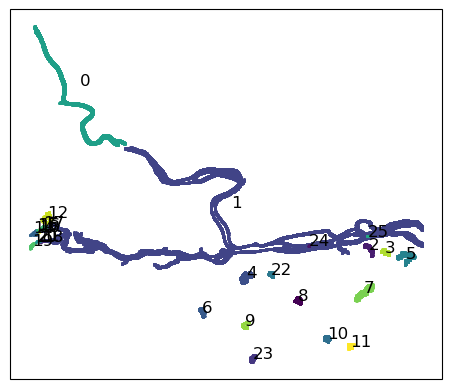

In [14]:
# Plot all clusters on which area extraction/polygonization will be performed
N_cluster = len(np.unique(res_data.lab_dbscan.values))
fig = plt.figure()
ax1 = fig.add_subplot(111, projection=tiler.crs)
cmap = plt.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, N_cluster)]
random.shuffle(colors)
for k, color in enumerate(colors, start=0):
    res_data2 = res_data[res_data.lab_dbscan == k]
    ax1.scatter(res_data2.longitude.values, res_data2.latitude.values, c=np.array([color]), s=1)
    lon_avg = (np.min(res_data2.longitude) + np.max(res_data2.longitude)) / 2
    lat_avg = (np.min(res_data2.latitude) + np.max(res_data2.latitude)) / 2
    ax1.annotate(k, xy=(lon_avg, lat_avg), xycoords='data', color='black', fontsize=12)
plt.show()

# Plotting ungridded FPDEM results

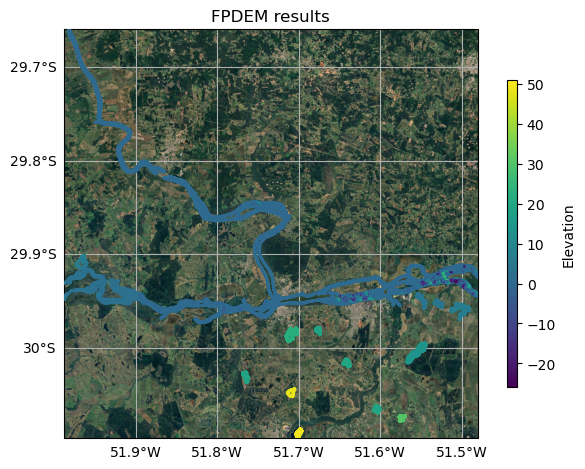

In [15]:
extent = [np.min(res_data.longitude.values), np.max(res_data.longitude.values), 
         np.min(res_data.latitude.values), np.max(res_data.latitude.values)]
hmin = min(res_data.elevation.values)
hmax = max(res_data.elevation.values)

fig = plt.figure(layout='tight')
ax = fig.add_subplot(1, 1, 1, projection=tiler.crs)
ax.set_title(f'FPDEM results')
ax.set_extent(extent, geodetic)
ax.add_image(tiler, 13)
cs = res_data.plot(ax=ax, kind='scatter', x='longitude', y='latitude', c="elevation", 
               zorder=5, transform=wgs84, s=1, vmin=hmin, vmax=hmax, colorbar=False)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=hmin, vmax=hmax))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.75, aspect=30, label='Elevation')
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

plt.show()

# Write FPDEM ungridded file

In [16]:
fpdem.res_pointcloud = res_data
fpdem.inputpixcfiles = inputpixcfiles
fpdem.inputvecfiles = inputvecfiles
fpdem.output_path = output_dir
fpdem.tile_name = tile_name
fpdem.first_date_name = first_date
fpdem.last_date_name = last_date

In [17]:
fpdem.write_fpdem_pointcloud_output()

2026-02-12 14:30:58,449 [INFO] Writing the ungridded netcdf with FPDEM results
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/src/toshp.py:37: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  'range_index', 'azimuth_index', 'time']].to_file(filename, driver=driver, schema=schema, crs=prj,
2026-02-12 14:31:00,453 [WARNING] Normalized/laundered field name: 'range_index' to 'range_inde'
2026-02-12 14:31:00,453 [WARNING] Normalized/laundered field name: 'azimuth_index' to 'azimuth_in'
2026-02-12 14:31:06,357 [INFO] Writing FPDEM pointcloud file
2026-02-12 14:31:06,599 [INFO] Write output file: OK


# Extract Area : Get Polygons of the AOI for rasterization

In [18]:
output_fpdem_pointcloud_name = compute_name(output_dir, FPDEM_POINTCLOUD_BASENAME, tile_name,
                                            first_date, last_date)
output_mask_name = os.path.join(output_dir, FPDEM_BASENAME + MASK_SUFFIX)


In [19]:
extract_area = Extract_Area(None, 
                            input_file=output_fpdem_pointcloud_name, 
                            output_file=output_mask_name, 
                            ch_ratio=plg_ch_ratio)

extract_area.ch_ratio = plg_ch_ratio
extract_area.output_path = output_dir

In [20]:
extract_area.load_input_extract_area()
extract_area.extract_area_polygons()

2026-02-12 14:31:06,757 [INFO] There are 26 clusters (on which to extract polygons for rasterization)


# Rasterization

In [21]:
output_fpdem_raster_name = compute_name(output_dir, FPDEM_RASTER_BASENAME, tile_name,
                                        first_date, last_date)

In [22]:
fpdem_raster = FPDEM_Raster(None, 
                            input_file=output_fpdem_pointcloud_name, 
                            output_file=output_fpdem_raster_name, 
                            mask=output_mask_name)
fpdem_raster.resolution = raster_resolution
fpdem_raster.mode = raster_mode
fpdem_raster.plot = plot

zone nb and letter: 22 J


2026-02-12 14:31:17,771 [INFO] The filtering (MAD, 3sigma) removed 872 points out of 69446.
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/scripts/process_raster.py:212: RuntimeWarning: Mean of empty slice
  dist_mean = np.nanmean(distances_filtered, axis=1)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/scripts/process_raster.py:213: RuntimeWarning: All-NaN slice encountered
  dist_min = np.nanmin(distances_filtered, axis=1)
/work/SWOT/swotdev/swotdev/stephag/floodplain_dem/scripts/process_raster.py:224: RuntimeWarning: invalid value encountered in divide
  z = np.nansum(elevation_tab / distances_filtered, axis=1) / np.nansum(1. / distances_filtered, axis=1)
/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/work/scratch/env/stephag/.conda/envs/FPDEM_eodag_env/lib/python3.12/site-packages/pyproj/cr

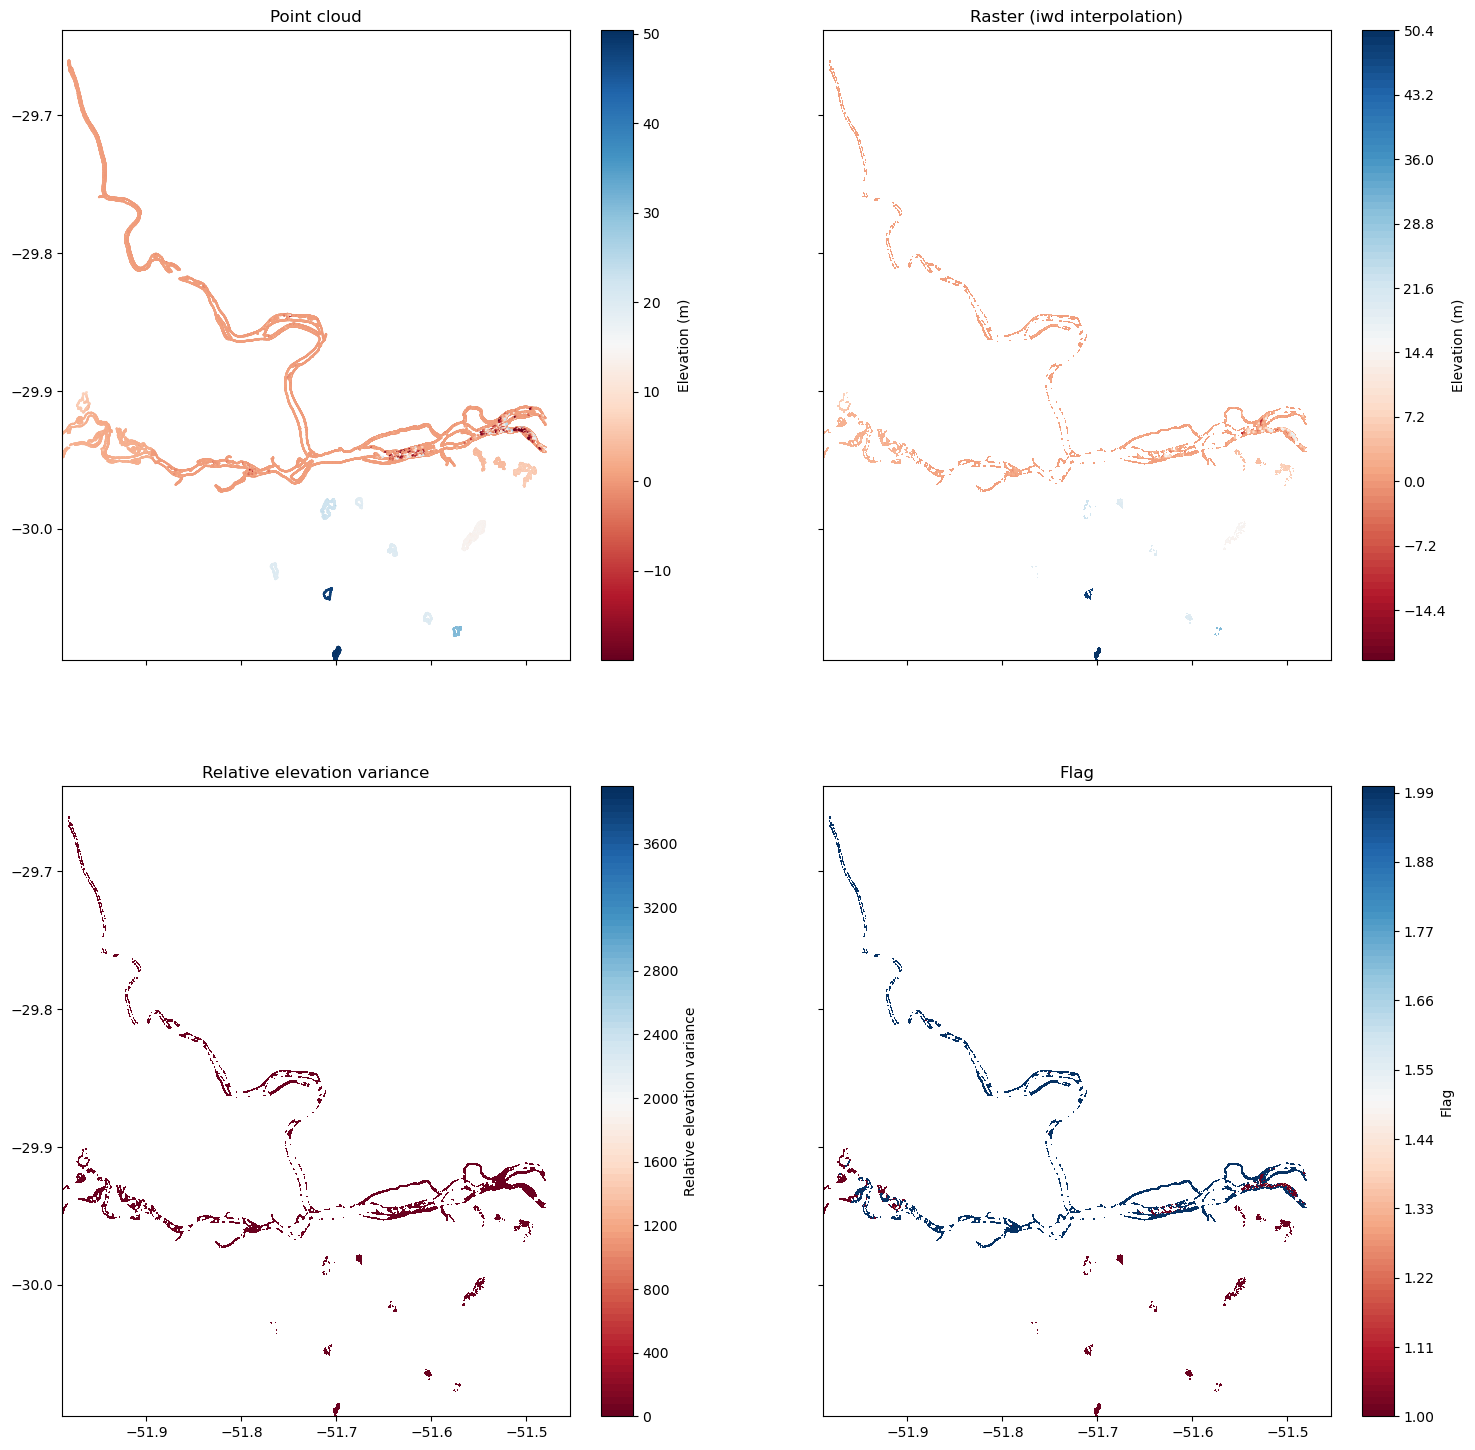

In [23]:
fpdem_raster.load_input_fpdem_raster()
fpdem_raster.compute_fpdem_raster()

In [24]:
fpdem_raster.write_fpdem_raster()

2026-02-12 14:32:04,157 [INFO] Writing FPDEM raster file
